# Week-32

In [7]:
from pathlib import Path
import re
import pandas as pd

LOG_DIR = Path(
    "/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/"
    "result_wlnm_dir_neg_sweep_train_ratios_10-90_"
    "pseudo_properties_Apocrita_neg_const/terminal_logs"
)

pattern = re.compile(
    r"constrained_neg=(\d+)\s+random_topup=(\d+)"
)

rows = []

for log_path in sorted(LOG_DIR.glob("*_terminal_log.txt")):
    with log_path.open(errors="replace") as log_file:
        for line in log_file:
            if "[NegPool]" not in line:
                continue

            match = pattern.search(line)
            if not match:
                continue

            role_links, topup_links = map(int, match.groups())

            if role_links > 0 and topup_links == 0:
                category = "Role constraints only"
            elif role_links > 0 and topup_links > 0:
                category = "Role constraints + random top-up"
            elif role_links == 0 and topup_links > 0:
                category = "Random top-up only"
            else:
                category = "Unclassified"

            rows.append({
                "Foodweb": log_path.name.replace(
                    "_tax_mass_wlnm_dir_neg_terminal_log.txt", ""
                ),
                "Category": category,
            })
            break

foodweb_pool_df = pd.DataFrame(rows)

category_order = [
    "Role constraints only",
    "Role constraints + random top-up",
    "Random top-up only",
]

summary_df = (
    foodweb_pool_df["Category"]
    .value_counts()
    .reindex(category_order, fill_value=0)
    .rename_axis("Negative sampling")
    .reset_index(name="Food webs")
)

summary_df["Percentage"] = (
    100 * summary_df["Food webs"] / len(foodweb_pool_df)
).round(2)

assert len(foodweb_pool_df) == 290

display(summary_df)

,Negative sampling,Food webs,Percentage
0,Role constraints only,207,71.38
1,Role constraints + random top-up,83,28.62
2,Random top-up only,0,0.00


[INFO] Validated Figure 2 configuration:
  version=WLNM_dir_neg
  foodweb_index=216
  eligibility=role_only
  role_constraints=5
  mass_eligibility_enabled=false
  negative_sampling=uniform_without_replacement
  negative_positive_ratio=2:1
  negative_topup_policy=uniform_remaining_nonlinks
  train_ratio=0.60
  classification_threshold=0.50
  experiment_id=21
  seed=1314098572
[INFO] Filtered food-web list by size: kept 160 / 290 (>= 40 nodes).

[INFO] Processing: Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2
[INFO] Link counts:
  Train=460
  TP=284
  FP=8
  FN=24
  Predicted=292
  Scores/labels=924


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_57628/2361686267.py:532: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
        That means the default return type will be a sparse array.
        Unless you use * instead of @, ** for matrix power, or you depend
        on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
        See the spmatrix to sparray migration guide for details.
        https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
        
  mat_data = scipy.io.loadmat(mat_file)


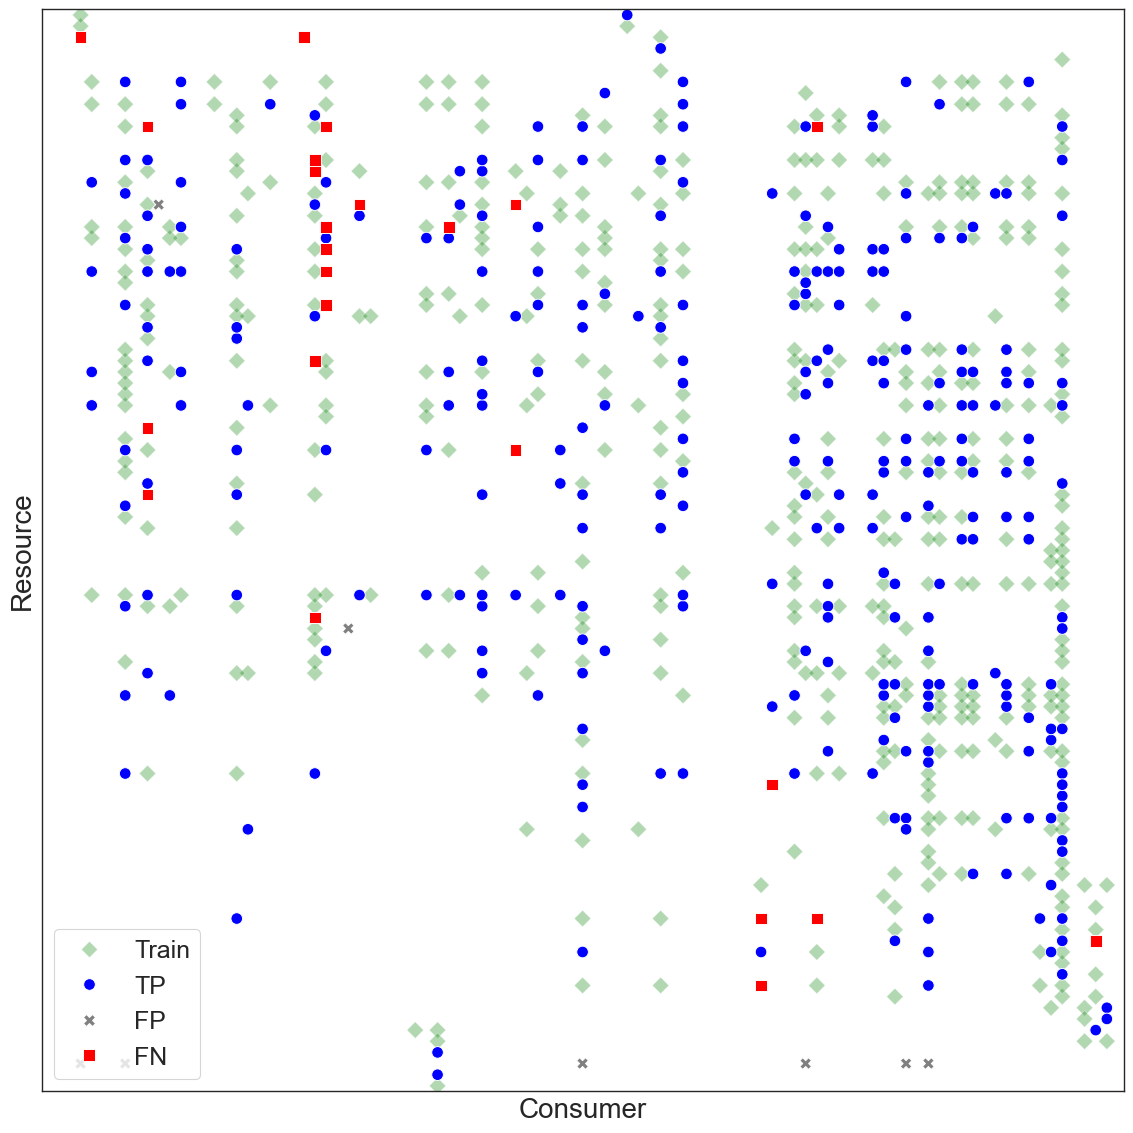

In [1]:
import os
import re
import scipy.io
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, csr_matrix


# Apply seaborn style
sns.set_theme(
    context="paper",
    style="white",
    font_scale=3,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        f"Could not locate repository root from {start}"
    )


REPO_ROOT = find_repo_root()


# =========================
# Figure controls
# =========================

MIN_NODES = 40

SHOW_TITLES = False
SHOW_TICKS = False

XLAB = "Consumer"
YLAB = "Resource"

PANEL_XTICK_FONTSIZES = [12]
PANEL_YTICK_FONTSIZES = [12]


# =========================
# Numeric axis labels and species key
# =========================

PRINT_SPECIES_KEY = False
EXPORT_SPECIES_KEY_FILE = True
SPECIES_KEY_FORMAT = "csv"

SPECIES_KEY_DIR = (
    REPO_ROOT
    / "docs/progress_notebooks_logs/2026/species_keys"
)

SPECIES_KEY_FORMAT = "csv"


# =========================
# Final role-only configuration
# =========================

TARGET_FOODWEB_1 = (
    "Grand Caricaie  marsh dominated by "
    "Cladietum marisci, not mown  ClControl2"
)

PANEL_LETTERS = ["a"]

K_TARGET = 10
TRAIN_RATIO = 60
CLASSIFICATION_THRESHOLD = 0.50

# Absolute-best local run among the 50 evaluated runs
EXPERIMENT_ID = 21
EXPECTED_SEED = 1314098572

ARTIFACT_TAG = (
    "wlnm_dir_neg_bb000_"
    f"exp{EXPERIMENT_ID:03d}_"
    f"seed{EXPECTED_SEED}"
)


# =========================
# Input paths
# =========================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_roleonly_figure2_"
        "clcontrol2_train60_bestfn_local"
    )
)

BASE_CSV_PATH = (
    RESULT_ROOT
    / "confusion_matrix_csv"
)

BASE_MAT_PATH = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
)

FOODWEB_METADATA_PATH = (
    BASE_MAT_PATH
    / "foodweb_metrics_ecosystem.csv"
)

RUN_MANIFEST_PATH = (
    RESULT_ROOT
    / "RUN_MANIFEST.txt"
)


# =========================
# Validate result manifest
# =========================

def read_manifest(path):
    values = {}

    for line in path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines():
        if "=" not in line:
            continue

        key, value = line.split("=", maxsplit=1)
        values[key.strip()] = value.strip()

    return values


required_base_files = {
    "Food-web metadata": FOODWEB_METADATA_PATH,
    "Run manifest": RUN_MANIFEST_PATH,
}

missing_base_files = [
    f"{label}:\n  {path}"
    for label, path in required_base_files.items()
    if not path.is_file()
]

if missing_base_files:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_base_files)
    )


manifest = read_manifest(RUN_MANIFEST_PATH)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "FoodwebIndex": "216",
    "Eligibility": "role_only",
    "RoleConstraints": "5",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": "uniform_without_replacement",
    "TargetNegativePositiveRatio": "2",
    "NegativeTopupPolicy": "uniform_remaining_nonlinks",
    "SubgraphK": str(K_TARGET),
    "TrainRatio": "0.60",
    "ClassificationThreshold": "0.50",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "AuxiliaryExportExperimentID": str(EXPERIMENT_ID),
    "ExpectedExportSeed": str(EXPECTED_SEED),
    "ExportAuxiliaryCSVs": "true",
    "RunStatus": "COMPLETE",
    "ExpectedAuxiliaryFiles": "6",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(key)

    if observed_value != expected_value:
        configuration_errors.append(
            f"{key}: expected {expected_value!r}, "
            f"observed {observed_value!r}"
        )

if configuration_errors:
    raise ValueError(
        "The selected Figure 2 results do not match "
        "the final role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )


print("[INFO] Validated Figure 2 configuration:")
print(f"  version={manifest['Version']}")
print(f"  foodweb_index={manifest['FoodwebIndex']}")
print(f"  eligibility={manifest['Eligibility']}")
print(f"  role_constraints={manifest['RoleConstraints']}")
print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)
print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)
print(
    "  negative_positive_ratio="
    f"{manifest['TargetNegativePositiveRatio']}:1"
)
print(
    "  negative_topup_policy="
    f"{manifest['NegativeTopupPolicy']}"
)
print(f"  train_ratio={manifest['TrainRatio']}")
print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)
print(
    "  experiment_id="
    f"{manifest['AuxiliaryExportExperimentID']}"
)
print(
    "  seed="
    f"{manifest['ExpectedExportSeed']}"
)


# =========================
# Load food-web metadata
# =========================

foodwebs_list_df = pd.read_csv(
    FOODWEB_METADATA_PATH
)


# =========================
# Filter by number of nodes
# =========================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


node_candidates = {
    "n_nodes",
    "num_nodes",
    "nodes",
    "nodecount",
    "n",
    "s",
    "species",
    "numspecies",
    "numberofspecies",
    "speciescount",
}

norm_map = {
    normalize_colname(column): column
    for column in foodwebs_list_df.columns
}

node_col = next(
    (
        norm_map[candidate]
        for candidate in node_candidates
        if candidate in norm_map
    ),
    None,
)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in "
        "foodweb_metrics_ecosystem.csv."
    )


foodwebs_list_df[node_col] = pd.to_numeric(
    foodwebs_list_df[node_col],
    errors="coerce",
)

before_n = len(foodwebs_list_df)

foodwebs_list_df = foodwebs_list_df[
    foodwebs_list_df[node_col] >= MIN_NODES
].copy()

after_n = len(foodwebs_list_df)

print(
    f"[INFO] Filtered food-web list by size: "
    f"kept {after_n} / {before_n} "
    f"(>= {MIN_NODES} nodes)."
)


# =========================
# Resolve target food web
# =========================

all_foodwebs = (
    foodwebs_list_df["Foodweb"]
    .astype(str)
    .tolist()
)


def resolve_foodweb(target_name, all_names):
    exact = [
        foodweb
        for foodweb in all_names
        if foodweb == target_name
    ]

    if exact:
        return exact[0]

    suffix_matches = [
        foodweb
        for foodweb in all_names
        if foodweb.removesuffix("_tax_mass") == target_name
    ]

    if len(suffix_matches) == 1:
        return suffix_matches[0]

    raise ValueError(
        f"TARGET_FOODWEB={target_name!r} was not found "
        "uniquely in the filtered food-web list."
    )


foodweb_iter = [
    resolve_foodweb(
        TARGET_FOODWEB_1,
        all_foodwebs,
    )
]


# =========================
# Build one-panel figure
# =========================

fig, ax = plt.subplots(
    1,
    1,
    figsize=(12, 12),
)

axs = [ax]

global_species_offset = 0


# =========================
# Iterate over selected food web
# =========================

for panel_idx, foodweb in enumerate(foodweb_iter):
    ax = axs[panel_idx]

    print(
        f"\n[INFO] Processing: "
        f"{foodweb.removesuffix('_tax_mass')}"
    )

    # =========================
    # Resolve artifact names
    # =========================

    artifact_prefix = (
        f"{foodweb}_"
        f"K_{K_TARGET}_"
        f"random_ratio{TRAIN_RATIO}_"
        f"{ARTIFACT_TAG}"
    )

    tp_file = (
        BASE_CSV_PATH
        / f"{artifact_prefix}_TP_links.csv"
    )

    fp_file = (
        BASE_CSV_PATH
        / f"{artifact_prefix}_FP_links.csv"
    )

    fn_file = (
        BASE_CSV_PATH
        / f"{artifact_prefix}_FN_links.csv"
    )

    train_file = (
        BASE_CSV_PATH
        / f"{artifact_prefix}_train_links.csv"
    )

    predicted_file = (
        BASE_CSV_PATH
        / f"{artifact_prefix}_predicted_links.csv"
    )

    scores_file = (
        BASE_CSV_PATH
        / f"{artifact_prefix}_scores_labels.csv"
    )

    mat_file = (
        BASE_MAT_PATH
        / f"{foodweb}.mat"
    )

    required_files = {
        "TP links": tp_file,
        "FP links": fp_file,
        "FN links": fn_file,
        "Training links": train_file,
        "Predicted links": predicted_file,
        "Scores and labels": scores_file,
        "Food-web MAT": mat_file,
    }

    missing_files = [
        f"{label}:\n  {path}"
        for label, path in required_files.items()
        if not path.is_file()
    ]

    if missing_files:
        raise FileNotFoundError(
            "The following Figure 2 inputs are missing:\n\n"
            + "\n\n".join(missing_files)
        )

    # =========================
    # Load link-level results
    # =========================

    tp = (
        pd.read_csv(tp_file)
        .dropna(subset=["Prey", "Predator"])
    )

    fp = (
        pd.read_csv(fp_file)
        .dropna(subset=["Prey", "Predator"])
    )

    fn = (
        pd.read_csv(fn_file)
        .dropna(subset=["Prey", "Predator"])
    )

    train = (
        pd.read_csv(train_file)
        .dropna(subset=["Prey", "Predator"])
    )

    predicted = (
        pd.read_csv(predicted_file)
        .dropna(subset=["Prey", "Predator"])
    )

    scores_labels = pd.read_csv(scores_file)

    print("[INFO] Link counts:")
    print(f"  Train={len(train):,}")
    print(f"  TP={len(tp):,}")
    print(f"  FP={len(fp):,}")
    print(f"  FN={len(fn):,}")
    print(f"  Predicted={len(predicted):,}")
    print(f"  Scores/labels={len(scores_labels):,}")

    if len(predicted) != len(tp) + len(fp):
        raise ValueError(
            "Predicted-link count does not equal TP + FP."
        )

    positive_labels = (
        pd.to_numeric(
            scores_labels["Label"],
            errors="coerce",
        )
        .eq(1)
        .sum()
    )

    if positive_labels != len(tp) + len(fn):
        raise ValueError(
            "Positive test-label count does not equal "
            "TP + FN."
        )

    # =========================
    # Load MAT adjacency and metadata
    # =========================

    mat_data = scipy.io.loadmat(mat_file)

    net = mat_data["net"]

    taxonomy = [
        (
            str(value[0])
            if isinstance(value, (list, np.ndarray))
            else str(value)
        )
        for value in mat_data["taxonomy"].flatten()
    ]

    mass = (
        mat_data["mass"]
        .flatten()
        .astype(float)
    )

    mass = np.round(
        mass * 1000.0,
        4,
    )

    # =========================
    # Sort species by mass
    # =========================

    taxonomy_df = pd.DataFrame({
        "Species": taxonomy,
        "Mass": mass,
    })

    taxonomy_df = (
        taxonomy_df
        .dropna()
        .sort_values(
            by="Mass",
            ascending=True,
        )
        .reset_index(drop=True)
    )

    sorted_species = taxonomy_df["Species"].tolist()

    species_index = {
        species: index
        for index, species in enumerate(sorted_species)
    }

    number_species = len(sorted_species)

    # Number species globally
    start_num = global_species_offset + 1

    species_to_num = {
        species: start_num + index
        for index, species in enumerate(sorted_species)
    }

    num_to_species = {
        start_num + index: species
        for index, species in enumerate(sorted_species)
    }

    # =========================
    # Optional species key
    # =========================

    if PRINT_SPECIES_KEY:
        key_df = taxonomy_df.copy()

        key_df["Number"] = np.arange(
            start_num,
            start_num + len(key_df),
        )

        key_df = (
            key_df[
                [
                    "Number",
                    "Species",
                    "Mass",
                ]
            ]
            .rename(
                columns={
                    "Mass": "Mass_mg",
                }
            )
        )

        key_df["Mass_mg"] = (
            key_df["Mass_mg"]
            .map(lambda value: f"{value:.4f}")
        )

        print(
            f"\nSpecies key for {foodweb}:"
        )

        print(
            key_df.to_string(index=False)
        )

        if EXPORT_SPECIES_KEY_FILE:
            SPECIES_KEY_DIR.mkdir(
                parents=True,
                exist_ok=True,
            )

            safe_foodweb = re.sub(
                r"[^A-Za-z0-9._-]+",
                "_",
                str(foodweb),
            ).strip("_")

            extension = (
                "tsv"
                if SPECIES_KEY_FORMAT.lower() == "tsv"
                else "csv"
            )

            output_path = (
                SPECIES_KEY_DIR
                / (
                    f"{safe_foodweb}_"
                    f"species_key.{extension}"
                )
            )

            separator = (
                "\t"
                if extension == "tsv"
                else ","
            )

            key_df.to_csv(
                output_path,
                sep=separator,
                index=False,
                encoding="utf-8",
            )

            print(
                f"\n[INFO] Saved species key: "
                f"{output_path.resolve()}"
            )

    # =========================
    # Preserve matrix conversion logic
    # =========================

    if isinstance(net, coo_matrix):
        net = net.tocsr()

    elif isinstance(net, (np.ndarray, list)):
        net = csr_matrix(net)

    idx_sorted = [
        taxonomy.index(species)
        for species in sorted_species
    ]

    adj_sorted = (
        net[
            np.ix_(
                idx_sorted,
                idx_sorted,
            )
        ]
        .toarray()
        .astype(float)
    )

    # =========================
    # Filter links to valid species
    # =========================

    def filter_valid_species(dataframe):
        return dataframe[
            dataframe["Prey"].isin(species_index)
            & dataframe["Predator"].isin(species_index)
        ].copy()


    tp = filter_valid_species(tp)
    fp = filter_valid_species(fp)
    fn = filter_valid_species(fn)
    train = filter_valid_species(train)

    # =========================
    # Build predation matrix rows
    # =========================

    def make_df(dataframe, label):
        return pd.DataFrame({
            "PreyIdx": (
                dataframe["Prey"]
                .map(species_index)
            ),
            "PredIdx": (
                dataframe["Predator"]
                .map(species_index)
            ),
            "Label": label,
        })


    df_pm = pd.concat(
        [
            make_df(tp, "TP"),
            make_df(fp, "FP"),
            make_df(fn, "FN"),
        ],
        ignore_index=True,
    )

    df_pm = (
        df_pm
        .dropna()
        .astype({
            "PreyIdx": int,
            "PredIdx": int,
        })
    )

    # =========================
    # Build training-link rows
    # =========================

    df_train = make_df(
        train,
        "Train",
    )

    df_train = (
        df_train
        .dropna()
        .astype({
            "PreyIdx": int,
            "PredIdx": int,
        })
    )

    # =========================
    # Plot training links first
    # =========================

    if not df_train.empty:
        sns.scatterplot(
            data=df_train,
            x="PredIdx",
            y="PreyIdx",
            hue="Label",
            style="Label",
            markers={
                "Train": "D",
            },
            palette={
                "Train": "green",
            },
            alpha=0.3,
            s=70,
            legend="brief",
            ax=ax,
        )

    # =========================
    # Plot TP, FP and FN
    # =========================

    sns.scatterplot(
        data=df_pm,
        x="PredIdx",
        y="PreyIdx",
        hue="Label",
        style="Label",
        markers={
            "TP": "o",
            "FP": "X",
            "FN": "s",
            "Train": "D",
        },
        palette={
            "TP": "blue",
            "FP": "gray",
            "FN": "red",
            "Train": "green",
        },
        s=70,
        ax=ax,
    )

    # =========================
    # Preserve original axis styling
    # =========================

    # Consumers: increasing body mass from left to right
    ax.set_xlim(
        -0.5,
        number_species - 0.5,
    )

    # Resources: increasing body mass from top to bottom
    ax.set_ylim(
        number_species - 0.5,
        -0.5,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_xlabel(
        XLAB,
        fontsize=20,
    )

    ax.set_ylabel(
        YLAB,
        fontsize=20,
    )

    if SHOW_TICKS:
        ax.set_xticks(
            range(number_species)
        )

        ax.set_yticks(
            range(number_species)
        )

        x_tick_fontsize = (
            PANEL_XTICK_FONTSIZES[
                panel_idx
            ]
        )

        y_tick_fontsize = (
            PANEL_YTICK_FONTSIZES[
                panel_idx
            ]
        )

        if USE_NUMERIC_AXIS_LABELS:
            x_labels = [
                str(species_to_num[species])
                for species in sorted_species
            ]

            ax.set_yticklabels(
                sorted_species,
                fontsize=y_tick_fontsize,
            )

            ax.set_xticklabels(
                x_labels,
                rotation=90,
                fontsize=x_tick_fontsize,
            )

            ax.set_yticklabels(
                y_labels,
                fontsize=y_tick_fontsize,
            )

        else:
            ax.set_xticklabels(
                sorted_species,
                rotation=90,
                fontsize=x_tick_fontsize,
            )

            ax.set_yticklabels(
                sorted_species_reversed,
                fontsize=y_tick_fontsize,
            )

        ax.tick_params(
            axis="both",
            which="both",
            length=3,
        )

    else:
        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_xticklabels([])
        ax.set_yticklabels([])

        ax.tick_params(
            axis="both",
            which="both",
            length=0,
        )

    if SHOW_TITLES:
        ax.set_title(
            foodweb,
            fontsize=12,
        )

    ax.legend(
        loc="lower left",
        prop={
            "size": 18,
        },
        title="",
    )

    global_species_offset += number_species


plt.tight_layout()
plt.show()

[INFO] Using Tukey-filtered inputs:
  Original: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_original_50x290_train90_thresh0p50_legacy_uppertriangular_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
  Directed-negative: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] Food webs satisfying Nodes >= 0: 290

=== Retained and paired food webs by metric ===


,Metric,Original retained food webs,Directed-negative retained food webs,Paired food webs,Original-only food webs,Directed-negative-only food webs
0,ROC-AUC,290,290,290,0,0
1,PR-AUC,290,290,290,0,0
2,F1,290,290,290,0,0
3,MCC,290,290,290,0,0
4,Precision,290,290,290,0,0
5,Recall,290,290,290,0,0
6,TSS,290,290,290,0,0



=== Tukey retention details for paired food webs ===


,Version,Metric,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,Directed-negative,F1,290,31,49.0,50
1,Directed-negative,PR-AUC,290,40,50.0,50
2,Directed-negative,Precision,290,38,48.5,50
3,Directed-negative,ROC-AUC,290,38,49.0,50
4,Directed-negative,Recall,290,32,50.0,50
5,Directed-negative,MCC,290,31,49.0,50
6,Directed-negative,TSS,290,31,49.0,50
7,Original,F1,290,38,49.0,50
8,Original,PR-AUC,290,38,50.0,50
9,Original,Precision,290,38,50.0,50



=== Tukey-filtered web-level predictive metric summary ===


,Version,Metric,FoodWebs,Mean,Median,SD,Variance
0,Directed-negative,F1,290,0.6652,0.7110,0.2276,0.0518
1,Directed-negative,PR-AUC,290,0.5035,0.5101,0.1780,0.0317
2,Directed-negative,Precision,290,0.9040,0.9706,0.1497,0.0224
3,Directed-negative,ROC-AUC,290,0.8788,0.9093,0.1113,0.0124
4,Directed-negative,Recall,290,0.5830,0.6153,0.2563,0.0657
5,Directed-negative,MCC,290,0.6206,0.6325,0.2194,0.0482
6,Directed-negative,TSS,290,0.5444,0.5597,0.2545,0.0648
7,Original,F1,290,0.6236,0.6710,0.1941,0.0377
8,Original,PR-AUC,290,0.5550,0.6030,0.1945,0.0378
9,Original,Precision,290,0.6706,0.7207,0.2022,0.0409



[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_legacy_uppertriangular_vs_dir_neg_roleonly_train90_thresh0p50_tukey_iqr1p5_min50pct.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_legacy_uppertriangular_vs_dir_neg_roleonly_train90_thresh0p50_tukey_iqr1p5_min50pct.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_legacy_uppertriangular_vs_dir_neg_roleonly_train90_thresh0p50_tukey_iqr1p5_min50pct.

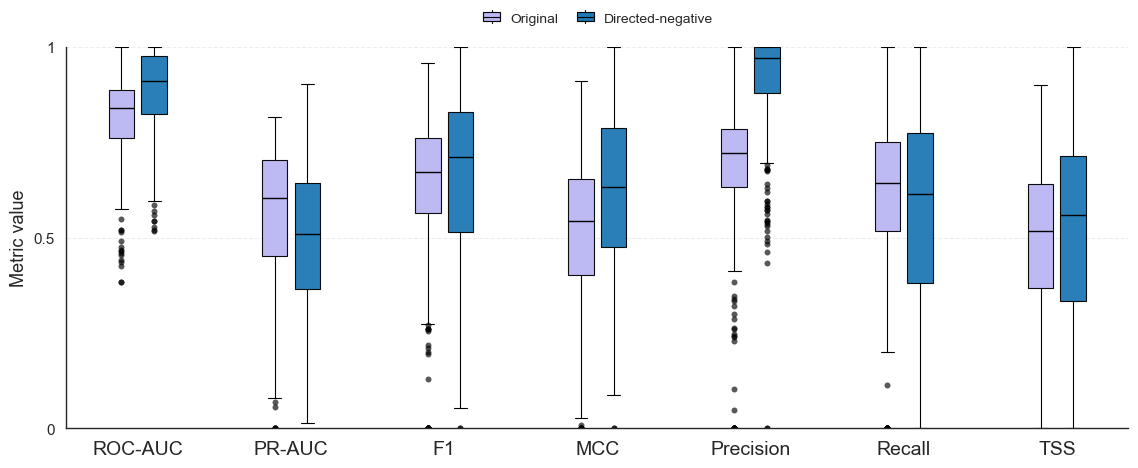

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.1,
)


# ============================================================
# Locate repository root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        f"Could not locate repository root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final configuration
# ============================================================
TRAIN_RATIO_TARGET = 90
CLASSIFICATION_THRESHOLD = 0.50
NODES_THRESHOLD = 0

ELIGIBILITY_MODE = "role_only"
MASS_ELIGIBILITY_ENABLED = False
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)


# ============================================================
# Corrected result roots
# ============================================================
ORIGINAL_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_original_50x290_train90_thresh0p50_"
        "legacy_uppertriangular_checkconnfalse_adaptivefalse_Apocrita"
    )
)

DIR_NEG_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)


# ============================================================
# Tukey-filtered figure inputs
# ============================================================
ORIGINAL_INPUT = (
    ORIGINAL_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

DIR_NEG_INPUT = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Publication output
# ============================================================
OUT_DIR = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_3_original_legacy_uppertriangular_vs_"
    "dir_neg_roleonly_train90_thresh0p50_"
    "tukey_iqr1p5_min50pct"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention_counts.csv"
)


# ============================================================
# Metrics
# ============================================================
METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

METRIC_ORDER = [
    metric
    for metric, _ in METRIC_SPECS
]

METRIC_LABELS = dict(METRIC_SPECS)

VERSION_ORDER = [
    "original",
    "dir_neg",
]

VERSION_LABELS = {
    "original": "Original",
    "dir_neg": "Directed-negative",
}

VERSION_PALETTE = {
    "original": "#BAB6F2",
    "dir_neg": "#1F78B4",
}

SHOW_WEB_LEVEL_FLIERS = True


# ============================================================
# Validate required inputs
# ============================================================
required_inputs = {
    "Corrected WLNM_original Tukey input": ORIGINAL_INPUT,
    "Final WLNM_dir_neg Tukey input": DIR_NEG_INPUT,
    "Food-web metadata": FOODWEB_CSV,
}

missing_inputs = [
    f"{label}:\n  {path}"
    for label, path in required_inputs.items()
    if not path.is_file()
]

if missing_inputs:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_inputs)
        + (
            "\n\nThe corrected WLNM_original result must first "
            "be transferred from Apocrita and processed with "
            "apply_wlnm_tukey_retention.py."
        )
    )

print("[INFO] Using Tukey-filtered inputs:")
print(f"  Original: {ORIGINAL_INPUT}")
print(f"  Directed-negative: {DIR_NEG_INPUT}")


# ============================================================
# Helpers
# ============================================================
def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(" ", "_")

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


def load_tukey_figure_input(
    path,
    version,
):
    df = pd.read_csv(path)

    required_columns = {
        "Foodweb",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    }

    missing_columns = (
        required_columns
        .difference(df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{path.name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    numeric_columns = [
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    df = df[
        df["Metric"].isin(METRIC_ORDER)
        & df["MetricFamily"].eq("predictive")
        & np.isclose(
            df["TrainRatio"],
            TRAIN_RATIO_TARGET,
            atol=1e-8,
            equal_nan=False,
        )
        & np.isclose(
            df["Threshold"],
            CLASSIFICATION_THRESHOLD,
            atol=1e-9,
            equal_nan=False,
        )
        & df["MeetsMinimumRetainedRuns"].eq(1)
        & df["MeanAfterTukey"].notna()
    ].copy()

    df["Version"] = version
    df["Value"] = df["MeanAfterTukey"]
    df["FW_KEY"] = (
        df["Foodweb"]
        .apply(normalize_fw_label)
    )

    duplicate_mask = df.duplicated(
        subset=[
            "FW_KEY",
            "Version",
            "Metric",
        ],
        keep=False,
    )

    if duplicate_mask.any():
        duplicated = (
            df.loc[
                duplicate_mask,
                [
                    "Foodweb",
                    "Version",
                    "Metric",
                ],
            ]
            .sort_values(
                [
                    "Metric",
                    "Foodweb",
                ]
            )
        )

        display(duplicated)

        raise ValueError(
            f"Duplicated foodweb–metric rows found in {path}"
        )

    return df


# ============================================================
# Load final Tukey-filtered values
# ============================================================
original_df = load_tukey_figure_input(
    ORIGINAL_INPUT,
    version="original",
)

dir_neg_df = load_tukey_figure_input(
    DIR_NEG_INPUT,
    version="dir_neg",
)

combined_df = pd.concat(
    [
        original_df,
        dir_neg_df,
    ],
    ignore_index=True,
)


# ============================================================
# Apply node-count filter
# ============================================================
metadata_df = pd.read_csv(
    FOODWEB_CSV
)

metadata_df.columns = [
    column.strip()
    for column in metadata_df.columns
]

foodweb_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
):
    raise ValueError(
        "Could not identify Foodweb and Nodes "
        "columns in the metadata file."
    )

metadata_df[nodes_column] = pd.to_numeric(
    metadata_df[nodes_column],
    errors="coerce",
)

metadata_df["FW_KEY"] = (
    metadata_df[foodweb_column]
    .apply(normalize_fw_label)
)

metadata_df = (
    metadata_df[
        [
            "FW_KEY",
            foodweb_column,
            nodes_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
)

allowed_fw_keys = set(
    metadata_df.loc[
        metadata_df[nodes_column]
        >= NODES_THRESHOLD,
        "FW_KEY",
    ]
)

print(
    f"[INFO] Food webs satisfying "
    f"Nodes >= {NODES_THRESHOLD}: "
    f"{len(allowed_fw_keys)}"
)

combined_df = combined_df[
    combined_df["FW_KEY"]
    .isin(allowed_fw_keys)
].copy()

if combined_df.empty:
    raise RuntimeError(
        "No retained food-web metrics remain "
        "after the node-count filter."
    )


# ============================================================
# Enforce paired food webs separately per metric
# ============================================================
paired_frames = []
pairing_rows = []

for metric in METRIC_ORDER:
    metric_df = combined_df[
        combined_df["Metric"].eq(metric)
    ].copy()

    original_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("original"),
            "FW_KEY",
        ]
    )

    dir_neg_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("dir_neg"),
            "FW_KEY",
        ]
    )

    common_keys = (
        original_keys
        .intersection(dir_neg_keys)
    )

    pairing_rows.append({
        "Metric": METRIC_LABELS[metric],
        "Original retained food webs": len(
            original_keys
        ),
        "Directed-negative retained food webs": len(
            dir_neg_keys
        ),
        "Paired food webs": len(
            common_keys
        ),
        "Original-only food webs": len(
            original_keys - dir_neg_keys
        ),
        "Directed-negative-only food webs": len(
            dir_neg_keys - original_keys
        ),
    })

    paired_metric_df = metric_df[
        metric_df["FW_KEY"]
        .isin(common_keys)
    ].copy()

    paired_frames.append(
        paired_metric_df
    )

plot_df = pd.concat(
    paired_frames,
    ignore_index=True,
)

if plot_df.empty:
    raise RuntimeError(
        "No paired food webs remain for plotting."
    )

pairing_table = pd.DataFrame(
    pairing_rows
)

print(
    "\n=== Retained and paired food webs "
    "by metric ==="
)

display(pairing_table)


# ============================================================
# Retention details
# ============================================================
retention_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["Version"] = (
    retention_table["Version"]
    .map(VERSION_LABELS)
)

retention_table["Metric"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "Version",
        "Metric",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention details "
    "for paired food webs ==="
)

display(retention_table)


# ============================================================
# Web-level summary
# ============================================================
summary_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        Mean=(
            "Value",
            "mean",
        ),
        Median=(
            "Value",
            "median",
        ),
        SD=(
            "Value",
            "std",
        ),
        Variance=(
            "Value",
            "var",
        ),
    )
)

summary_table["Version"] = (
    summary_table["Version"]
    .map(VERSION_LABELS)
)

summary_table["Metric"] = (
    summary_table["Metric"]
    .map(METRIC_LABELS)
)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[column] = (
        summary_table[column]
        .round(4)
    )

print(
    "\n=== Tukey-filtered web-level "
    "predictive metric summary ==="
)

display(summary_table)


# ============================================================
# Custom miniature boxplot legend
# ============================================================
class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )
        linewidth = orig_handle.get(
            "linewidth",
            0.6,
        )

        center_x = (
            xdescent
            + 0.5 * width
        )

        center_y = (
            ydescent
            + 0.44 * height
        )

        box_width = (
            0.8 * width
        )

        box_height = (
            0.8 * height
        )

        box_x = (
            center_x
            - box_width / 2
        )

        box_y = (
            center_y
            - box_height / 2
        )

        whisker_top_y = (
            box_y
            + box_height
            + 0.18 * height
        )

        whisker_bottom_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (
                box_x,
                box_y,
            ),
            box_width,
            box_height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_width,
            ],
            [
                center_y,
                center_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        upper_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                box_y + box_height,
                whisker_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        lower_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                whisker_bottom_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            upper_whisker,
            lower_whisker,
        ]


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(
    figsize=(11.5, 4.8)
)

group_gap = 1.5

group_centers = (
    1.0
    + np.arange(
        len(METRIC_SPECS)
    )
    * group_gap
)

offsets = {
    "original": -0.16,
    "dir_neg": 0.16,
}

box_width = 0.25

for version in VERSION_ORDER:
    version_data = []
    version_positions = []

    for metric_index, (
        metric,
        metric_label,
    ) in enumerate(METRIC_SPECS):

        values = (
            plot_df.loc[
                (
                    plot_df["Version"]
                    .eq(version)
                )
                & (
                    plot_df["Metric"]
                    .eq(metric)
                ),
                "Value",
            ]
            .dropna()
            .to_numpy()
        )

        if len(values) == 0:
            continue

        version_data.append(
            values
        )

        version_positions.append(
            group_centers[metric_index]
            + offsets[version]
        )

    ax.boxplot(
        version_data,
        positions=version_positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops={
            "facecolor": VERSION_PALETTE[version],
            "edgecolor": "black",
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.0,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.2,
            "alpha": 0.65,
        },
    )


# ============================================================
# Axes and legend
# ============================================================
legend_handles = [
    {
        "facecolor": VERSION_PALETTE[version],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for version in VERSION_ORDER
]

ax.set_xlim(
    group_centers[0] - 0.7,
    group_centers[-1] + 0.7,
)

ax.set_ylim(
    0,
    1.0,
)

ax.set_xticks(
    group_centers,
    labels=[
        metric_label
        for _, metric_label in METRIC_SPECS
    ],
)

plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=14,
)

ax.set_ylabel(
    "Metric value",
    fontsize=13,
)

ax.set_xlabel("")

ax.set_yticks(
    [
        0,
        0.5,
        1.0,
    ]
)

ax.set_yticklabels(
    [
        "0",
        "0.5",
        "1",
    ]
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.35,
)

ax.legend(
    handles=legend_handles,
    labels=[
        VERSION_LABELS[version]
        for version in VERSION_ORDER
    ],
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        1.03,
    ),
    ncol=len(VERSION_ORDER),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(
    ax=ax
)

plt.tight_layout()


# ============================================================
# Export
# ============================================================
fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary_table.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(
    f"  PNG: {PNG_PATH}"
)

print(
    f"  SVG: {SVG_PATH}"
)

print(
    f"  PDF: {PDF_PATH}"
)

print(
    f"  Summary: {SUMMARY_PATH}"
)

print(
    f"  Retention counts: {RETENTION_PATH}"
)

print(
    "\n[INFO] Final directed configuration:"
)

print(
    f"  check_connectivity={CHECK_CONNECTIVITY}"
)

print(
    f"  adaptive_connectivity={ADAPTIVE_CONNECTIVITY}"
)

print(
    f"  classification_threshold="
    f"{CLASSIFICATION_THRESHOLD}"
)

print(
    f"  retention_protocol={PROTOCOL_NAME}"
)

plt.show()

[INFO] Validated final role-only configuration:
  scenario=role_only_5_role_constraints_checkconnfalse_adaptivefalse_threshold0p50
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_role_pool_then_uniform_remaining_nonlinks_topup
  target_negative_positive_ratio=2
  classification_threshold=0.50
  check_connectivity=false
  adaptive_connectivity=false
  number_of_experiments=50
  train_ratio_range=0.10:0.10:0.90
  retention_protocol=tukey_iqr_1p5_min50pct_threshold0p50_v1
[INFO] Food webs after node filter: 290
[INFO] Training ratios: [10, 20, 30, 40, 50, 60, 70, 80, 90]
[INFO] Ecosystems: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']

=== Tukey retention by training ratio and metric ===


,TRAINRATIO,Metric,MetricLabel,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,10,F1Score,F1,290,38,50.0,50
1,10,PR_AUC,PR-AUC,290,40,49.0,50
2,10,Precision,Precision,290,38,49.0,50
3,10,ROC_AUC,ROC-AUC,290,41,49.0,50
4,10,Recall,Recall,290,38,50.0,50
...,...,...,...,...,...,...,...
58,90,Precision,Precision,290,38,48.5,50
59,90,ROC_AUC,ROC-AUC,290,38,49.0,50
60,90,Recall,Recall,290,32,50.0,50
61,90,TestMCC,MCC,290,31,49.0,50


[INFO] Food webs represented: 290

[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_4_predictive_metrics_by_train_ratio_roleonly_5constraints_checkconnfalse_adaptivefalse_thresh0p50_tukey_iqr1p5_min50pct.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_4_predictive_metrics_by_train_ratio_roleonly_5constraints_checkconnfalse_adaptivefalse_thresh0p50_tukey_iqr1p5_min50pct.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_4_predictiv

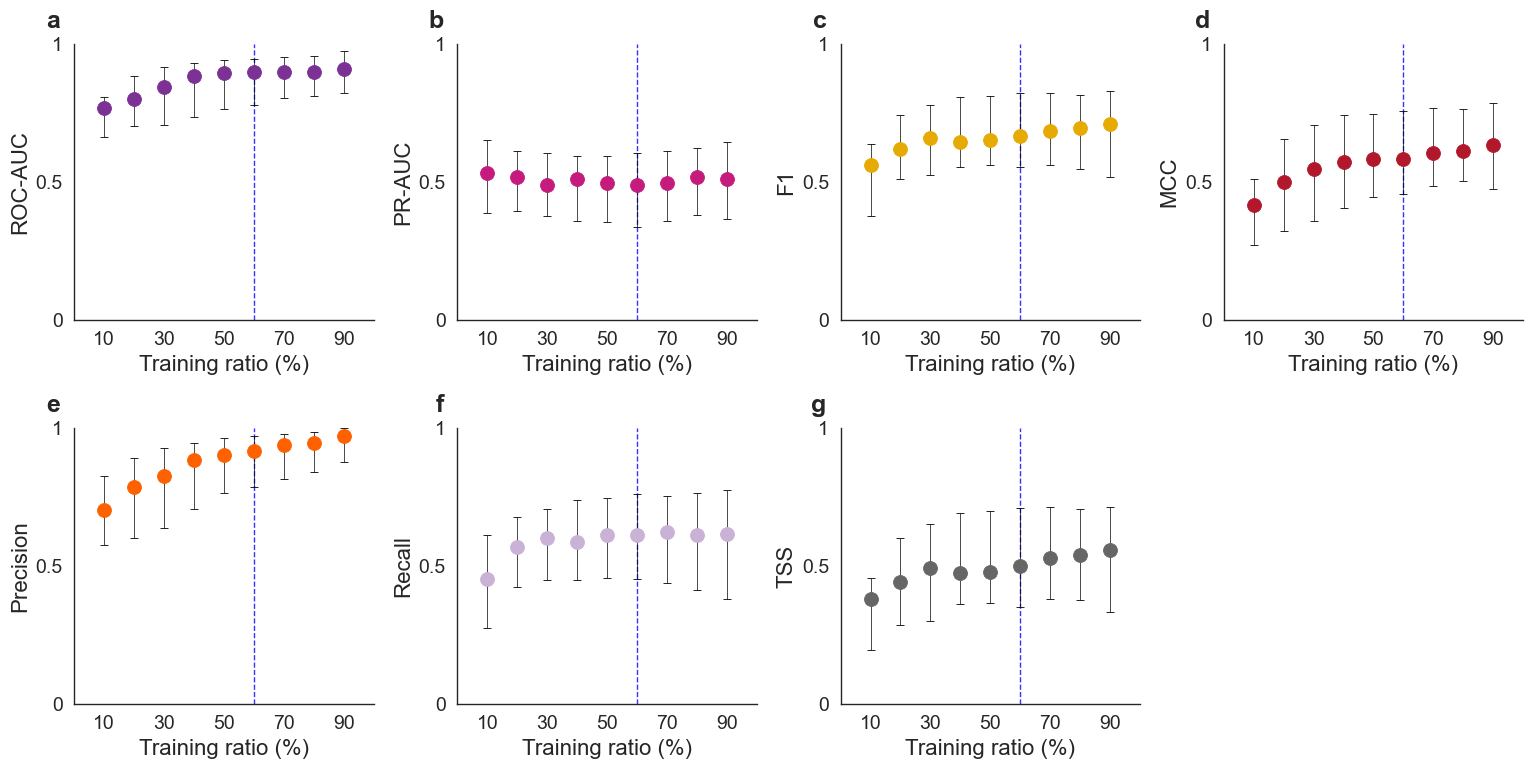

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display


sns.set_context(
    "paper",
    font_scale=1.35,
)

sns.set_style("white")


# ============================================================
# Locate repository root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        f"Could not locate repository root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only experimental configuration
# ============================================================
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

NODES_THRESHOLD = 0

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "role_only_5_role_constraints_"
    "checkconnfalse_adaptivefalse_threshold0p50"
)


# ============================================================
# Final role-only result root
# ============================================================
RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

RETENTION_MANIFEST_PATH = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

RESULTS_FILE = (
    RETENTION_ROOT
    / "figure_inputs"
    / "predictive_train10-90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Output paths
# ============================================================
OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_4_predictive_metrics_by_train_ratio_"
    "roleonly_5constraints_checkconnfalse_"
    "adaptivefalse_thresh0p50_"
    "tukey_iqr1p5_min50pct"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention.csv"
)


# ============================================================
# Metrics
# ============================================================
METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

METRIC_PALETTE = {
    "ROC-AUC": "#7B3294",
    "PR-AUC": "#C51B7D",
    "F1": "#E6AB02",
    "MCC": "#B2182B",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "TSS": "#666666",
}

SHOW_GRID = False

Y_MIN = 0.0
Y_MAX = 1.0

INDEPENDENT_Y = False
Y_PADDING = 0.02

REFERENCE_TRAIN_RATIO = 60


# ============================================================
# Validate required files
# ============================================================
required_files = {
    "Tukey retention manifest": RETENTION_MANIFEST_PATH,
    "Tukey-filtered predictive input": RESULTS_FILE,
    "Food-web metadata": FOODWEB_CSV,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n\n"
        + "\n\n".join(missing_files)
    )


# ============================================================
# Validate final role-only configuration
# ============================================================
with RETENTION_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    retention_manifest = json.load(file)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Condition": EXPECTED_SCENARIO,
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": (
        "uniform_role_pool_then_uniform_remaining_nonlinks_topup"
    ),
    "TargetNegativePositiveRatio": "2",
    "NumExperiments": "50",
    "TrainRatioRange": "0.10:0.10:0.90",
    "ClassificationThreshold": "0.50",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(key)

    if observed_value != expected_value:
        configuration_errors.append(
            f"{key}: expected {expected_value!r}, "
            f"observed {observed_value!r}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the "
        "final role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )

if retention_manifest.get("scenario") != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {retention_manifest.get('scenario')}"
    )

if not np.isclose(
    float(retention_manifest.get("classification_threshold")),
    CLASSIFICATION_THRESHOLD,
    atol=1e-9,
):
    raise ValueError(
        "The Tukey retention threshold does not match "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

print("[INFO] Validated final role-only configuration:")
print(f"  scenario={manifest['Condition']}")
print(f"  eligibility={manifest['Eligibility']}")
print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)
print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)
print(
    "  target_negative_positive_ratio="
    f"{manifest['TargetNegativePositiveRatio']}"
)
print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)
print(
    "  check_connectivity="
    f"{manifest['CheckConnectivity']}"
)
print(
    "  adaptive_connectivity="
    f"{manifest['AdaptiveConnectivity']}"
)
print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)
print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)
print(f"  retention_protocol={PROTOCOL_NAME}")


# ============================================================
# Food-web name normalisation
# ============================================================
def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(
        " ",
        "_",
    )

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(
            token,
            "_",
        )

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


# ============================================================
# Load Tukey-filtered web-level results
# ============================================================
df = pd.read_csv(
    RESULTS_FILE
)

required_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "Metric",
    "MetricLabel",
    "MetricFamily",
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
}

missing_columns = (
    required_columns
    .difference(df.columns)
)

if missing_columns:
    raise ValueError(
        f"{RESULTS_FILE.name} is missing required columns: "
        f"{sorted(missing_columns)}"
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )


# ============================================================
# Enforce final role-only configuration
# ============================================================
df = df[
    df["Scenario"].eq(EXPECTED_SCENARIO)
    & df["Version"].eq("WLNM_dir_neg")
    & df["MetricFamily"].eq("predictive")
    & df["Metric"].isin(METRICS)
    & np.isclose(
        df["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
    & df["MeetsMinimumRetainedRuns"].eq(1)
    & df["MeanAfterTukey"].notna()
].copy()

if df.empty:
    raise RuntimeError(
        "No retained predictive results remain after "
        "applying the final role-only configuration."
    )

df["TRAINRATIO"] = (
    df["TrainRatio"]
    .round()
    .astype(int)
)

df["Value"] = (
    df["MeanAfterTukey"]
)

df["FW_KEY"] = (
    df["Foodweb"]
    .apply(normalize_fw_label)
)


# ============================================================
# Validate expected training ratios
# ============================================================
expected_train_ratios = list(
    range(
        10,
        100,
        10,
    )
)

observed_train_ratios = sorted(
    df["TRAINRATIO"]
    .dropna()
    .unique()
    .tolist()
)

if observed_train_ratios != expected_train_ratios:
    raise ValueError(
        "Unexpected training-ratio coverage:\n"
        f"  expected: {expected_train_ratios}\n"
        f"  observed: {observed_train_ratios}"
    )


# ============================================================
# Validate unique web-level observations
# ============================================================
duplicate_mask = df.duplicated(
    subset=[
        "FW_KEY",
        "TRAINRATIO",
        "Metric",
    ],
    keep=False,
)

if duplicate_mask.any():
    duplicated = (
        df.loc[
            duplicate_mask,
            [
                "Foodweb",
                "TRAINRATIO",
                "Metric",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "TRAINRATIO",
                "Foodweb",
            ]
        )
    )

    display(duplicated)

    raise ValueError(
        "Duplicated Foodweb × TrainRatio × Metric "
        "rows were found."
    )


# ============================================================
# Load food-web metadata
# ============================================================
metadata = pd.read_csv(
    FOODWEB_CSV
)

metadata.columns = [
    column.strip()
    for column in metadata.columns
]

foodweb_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

ecosystem_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "ecosystem",
            "ecosystemtype",
            "ecosystem_type",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
    or ecosystem_column is None
):
    raise ValueError(
        "Could not identify Foodweb, Nodes, and "
        "Ecosystem columns in the metadata."
    )

metadata[nodes_column] = pd.to_numeric(
    metadata[nodes_column],
    errors="coerce",
)

metadata["FW_KEY"] = (
    metadata[foodweb_column]
    .apply(normalize_fw_label)
)

duplicate_metadata = metadata.duplicated(
    subset=["FW_KEY"],
    keep=False,
)

if duplicate_metadata.any():
    inconsistent_metadata = (
        metadata.loc[
            duplicate_metadata,
            [
                "FW_KEY",
                nodes_column,
                ecosystem_column,
            ],
        ]
        .groupby("FW_KEY")
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = inconsistent_metadata[
        (
            inconsistent_metadata[nodes_column] > 1
        )
        | (
            inconsistent_metadata[ecosystem_column] > 1
        )
    ]

    if not inconsistent_metadata.empty:
        display(inconsistent_metadata)

        raise ValueError(
            "Conflicting metadata were found for one or "
            "more normalised food-web names."
        )

metadata = (
    metadata[
        [
            "FW_KEY",
            nodes_column,
            ecosystem_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
    .rename(
        columns={
            nodes_column: "Nodes",
            ecosystem_column: "Ecosystem",
        }
    )
)


# ============================================================
# Merge metadata and apply node filter
# ============================================================
df = df.merge(
    metadata,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_metadata = (
    df.loc[
        (
            df["Nodes"].isna()
            | df["Ecosystem"].isna()
        ),
        "Foodweb",
    ]
    .drop_duplicates()
    .sort_values()
)

if not missing_metadata.empty:
    display(
        missing_metadata.to_frame(
            name="Foodweb"
        )
    )

    raise ValueError(
        "Food-web metadata could not be matched for "
        f"{len(missing_metadata)} food webs."
    )

df = df[
    df["Nodes"] >= NODES_THRESHOLD
].copy()

if df.empty:
    raise RuntimeError(
        f"No food webs remain after applying "
        f"Nodes >= {NODES_THRESHOLD}."
    )

print(
    f"[INFO] Food webs after node filter: "
    f"{df['FW_KEY'].nunique()}"
)

print(
    "[INFO] Training ratios: "
    f"{sorted(df['TRAINRATIO'].unique().tolist())}"
)

print(
    "[INFO] Ecosystems: "
    f"{sorted(df['Ecosystem'].dropna().unique().tolist())}"
)


# ============================================================
# Retention report
# ============================================================
retention_table = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["MetricLabel"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "TRAINRATIO",
        "Metric",
        "MetricLabel",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention by training ratio "
    "and metric ==="
)

display(
    retention_table
)


# ============================================================
# Across-food-web summary
# ============================================================
summary = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        median=(
            "Value",
            "median",
        ),
        q25=(
            "Value",
            lambda values: values.quantile(0.25),
        ),
        q75=(
            "Value",
            lambda values: values.quantile(0.75),
        ),
        mean=(
            "Value",
            "mean",
        ),
        sd=(
            "Value",
            "std",
        ),
        n_webs=(
            "FW_KEY",
            "nunique",
        ),
    )
)

summary["MetricLabel"] = (
    summary["Metric"]
    .map(METRIC_LABELS)
)

train_ratios = sorted(
    summary["TRAINRATIO"]
    .unique()
    .tolist()
)

print(
    f"[INFO] Food webs represented: "
    f"{df['FW_KEY'].nunique()}"
)


# ============================================================
# Consistent metric colours
# ============================================================
metric_colors = {
    metric: METRIC_PALETTE[
        METRIC_LABELS[metric]
    ]
    for metric in METRICS
}


# ============================================================
# Final plot
# ============================================================
number_of_metrics = len(METRICS)

number_of_rows = 2

number_of_columns = int(
    np.ceil(
        number_of_metrics
        / number_of_rows
    )
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(
        4 * number_of_columns,
        8.0,
    ),
    sharex=False,
    sharey=False,
)

axes = np.asarray(
    axes
).reshape(
    number_of_rows,
    number_of_columns,
)

axes_flat = axes.flatten()

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

for index, metric in enumerate(METRICS):
    ax = axes_flat[index]

    panel_df = (
        summary[
            summary["Metric"].eq(metric)
        ]
        .sort_values("TRAINRATIO")
    )

    if panel_df.empty:
        ax.set_axis_off()
        continue

    x_values = (
        panel_df["TRAINRATIO"]
        .to_numpy()
    )

    median_values = (
        panel_df["median"]
        .to_numpy()
    )

    error_values = np.vstack(
        [
            (
                panel_df["median"]
                - panel_df["q25"]
            ).to_numpy(),
            (
                panel_df["q75"]
                - panel_df["median"]
            ).to_numpy(),
        ]
    )

    color = metric_colors[metric]

    ax.errorbar(
        x_values,
        median_values,
        yerr=error_values,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    ax.axvline(
        x=REFERENCE_TRAIN_RATIO,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    if INDEPENDENT_Y:
        local_minimum = max(
            Y_MIN,
            panel_df["q25"].min()
            - Y_PADDING,
        )

        local_maximum = min(
            Y_MAX,
            panel_df["q75"].max()
            + Y_PADDING,
        )

        if np.isclose(
            local_minimum,
            local_maximum,
        ):
            local_minimum = max(
                Y_MIN,
                local_minimum - 0.02,
            )

            local_maximum = min(
                Y_MAX,
                local_maximum + 0.02,
            )

        ax.set_ylim(
            local_minimum,
            local_maximum,
        )

    else:
        ax.set_ylim(
            Y_MIN,
            Y_MAX,
        )

        ax.set_yticks(
            [
                0,
                0.5,
                1.0,
            ]
        )

        ax.set_yticklabels(
            [
                "0",
                "0.5",
                "1",
            ]
        )

    if SHOW_GRID:
        ax.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.30,
        )
    else:
        ax.grid(False)

    visible_ticks = [
        ratio
        for ratio in [
            10,
            30,
            50,
            70,
            90,
        ]
        if ratio in train_ratios
    ]

    ax.set_xticks(
        visible_ticks
    )

    ax.set_xticklabels(
        [
            str(ratio)
            for ratio in visible_ticks
        ]
    )

    ax.set_xlim(
        min(train_ratios) - 10,
        max(train_ratios) + 10,
    )

    ax.set_xlabel(
        "Training ratio (%)",
        fontsize=16,
    )

    ax.set_ylabel(
        METRIC_LABELS[metric],
        fontsize=16,
    )

    ax.set_title("")

    if index < len(panel_letters):
        ax.annotate(
            panel_letters[index],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(
        axis="both",
        labelsize=14,
    )

    sns.despine(
        ax=ax
    )


# ============================================================
# Hide unused panels
# ============================================================
for index in range(
    number_of_metrics,
    len(axes_flat),
):
    axes_flat[index].set_axis_off()


# ============================================================
# Layout and export
# ============================================================
fig.tight_layout(
    rect=[
        0.03,
        0,
        1,
        0.985,
    ]
)

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(f"  PNG: {PNG_PATH}")
print(f"  SVG: {SVG_PATH}")
print(f"  PDF: {PDF_PATH}")
print(f"  Summary: {SUMMARY_PATH}")
print(f"  Retention: {RETENTION_PATH}")

plt.show()

[INFO] Validated final role-only configuration:
  scenario=role_only_5_role_constraints_checkconnfalse_adaptivefalse_threshold0p50
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_role_pool_then_uniform_remaining_nonlinks_topup
  target_negative_positive_ratio=2
  classification_threshold=0.50
  check_connectivity=false
  adaptive_connectivity=false
  number_of_experiments=50
  train_ratio_range=0.10:0.10:0.90
  retention_protocol=tukey_iqr_1p5_min50pct_threshold0p50_v1
[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/ecological_train60_after_tukey.csv
[INFO] Loaded outlier-filtered web-level rows: 1,158
[INFO] Food webs represented: 290
[INFO] Plotting rows after empirical/mean-pseudo expansion: 2,316
[INFO] Each food web contributes one empirical value and one filter

,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns,MaxRetainedRuns
0,Connectance,290,296,37,50.0,50
1,MeanGenerality,290,350,40,49.0,50
2,MeanTrophicHeight,288,905,31,46.0,50
3,MeanVulnerability,290,257,41,50.0,50


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/fig5_wlnm_dir_neg_train60_roleonly_5constraints_checkconnfalse_adaptivefalse_threshold0p50_tukey_filtered.png


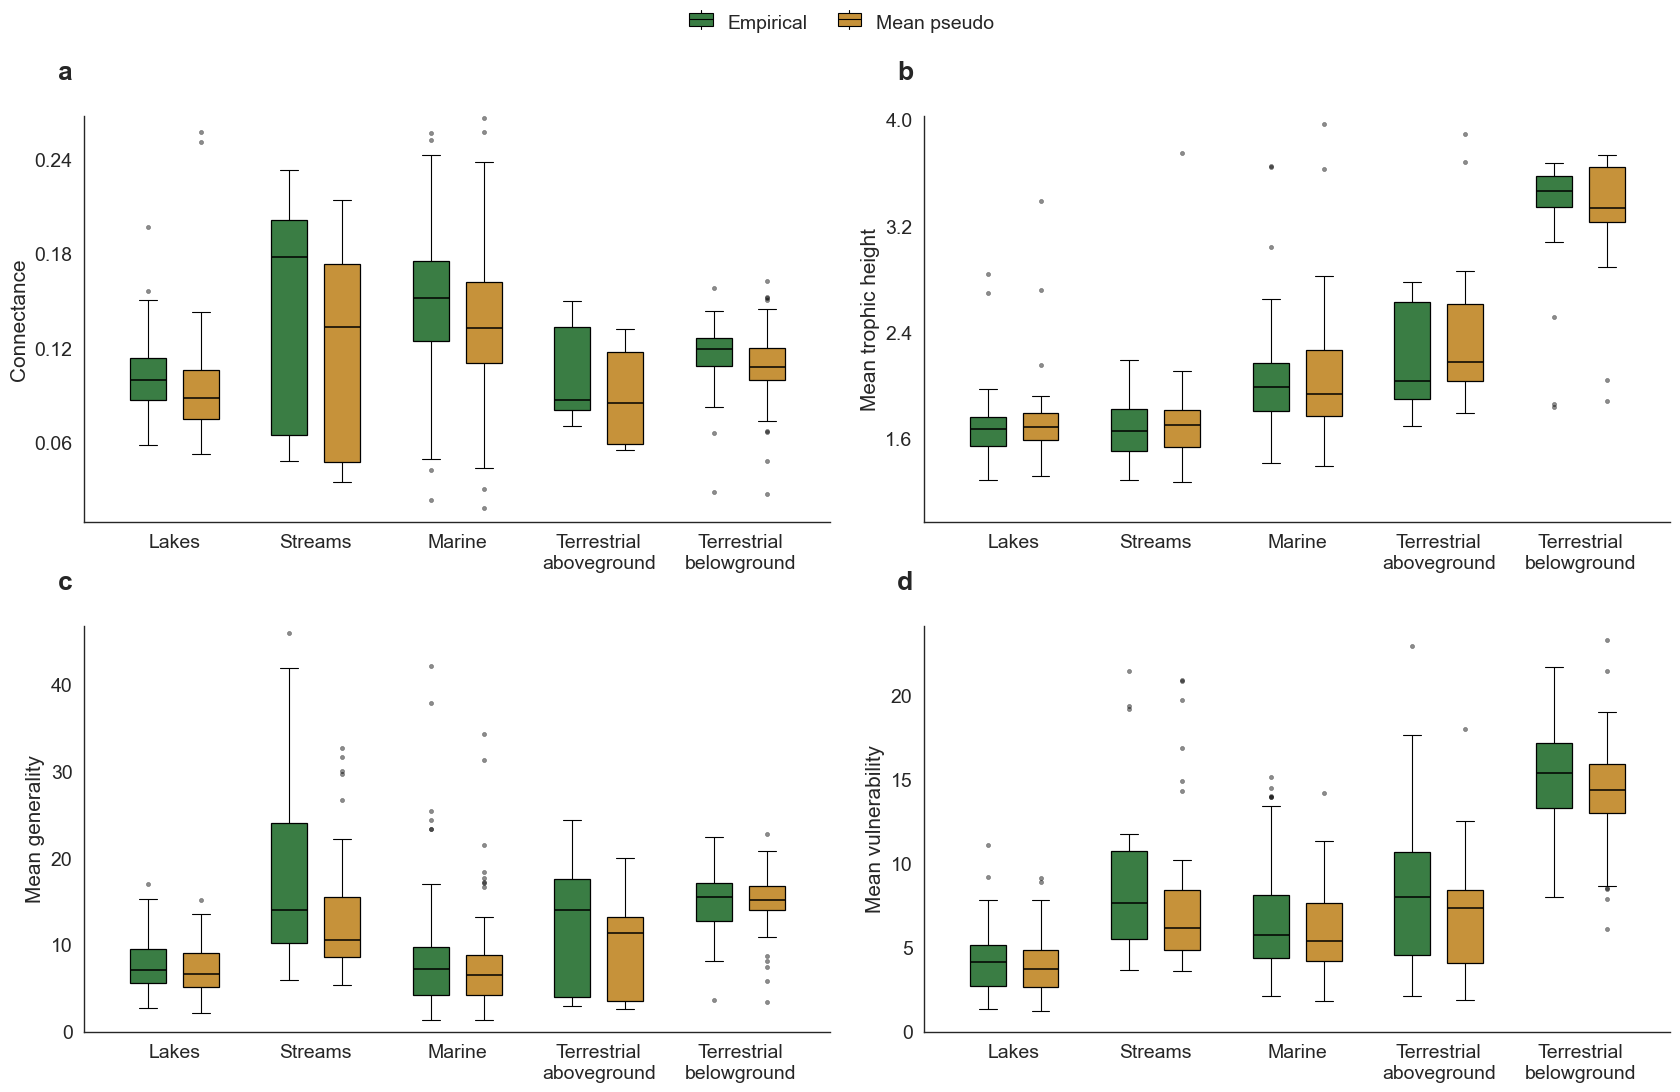

In [4]:
import json
import math

import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.15,
)


# ============================================================
# Locate repo root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for path in [start, *start.parents]:
        if (
            (path / "src/matlab").exists()
            and (path / "docs").exists()
        ):
            return path

    raise RuntimeError(
        f"Could not locate repo root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only data configuration
# ============================================================

TRAIN_RATIO = 60
CLASSIFICATION_THRESHOLD = 0.50

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "role_only_5_role_constraints_"
    "checkconnfalse_adaptivefalse_threshold0p50"
)


# ============================================================
# Final role-only result input
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

ECOLOGICAL_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / f"ecological_train{TRAIN_RATIO}_after_tukey.csv"
)

RETENTION_MANIFEST = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

FOODWEB_METADATA = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUT_PATH = (
    OUT_DIR
    / (
        f"fig5_wlnm_dir_neg_train{TRAIN_RATIO}_"
        "roleonly_5constraints_"
        "checkconnfalse_adaptivefalse_"
        "threshold0p50_tukey_filtered.png"
    )
)


# ============================================================
# Validate required files
# ============================================================

required_files = {
    "Tukey-filtered ecological input": ECOLOGICAL_INPUT,
    "Food-web metadata": FOODWEB_METADATA,
    "Tukey retention manifest": RETENTION_MANIFEST,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n\n"
        + "\n\n".join(missing_files)
    )


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST.open(
    "r",
    encoding="utf-8",
) as handle:
    retention_manifest = json.load(handle)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Condition": EXPECTED_SCENARIO,
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": (
        "uniform_role_pool_then_uniform_remaining_nonlinks_topup"
    ),
    "TargetNegativePositiveRatio": "2",
    "NumExperiments": "50",
    "TrainRatioRange": "0.10:0.10:0.90",
    "ClassificationThreshold": "0.50",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected in expected_manifest.items():
    observed = manifest.get(key)

    if observed is None:
        configuration_errors.append(
            f"{key}: missing"
        )
    elif str(observed).casefold() != str(expected).casefold():
        configuration_errors.append(
            f"{key}: expected {expected}, found {observed}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the final "
        "role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if (
    observed_threshold is None
    or not np.isclose(
        float(observed_threshold),
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
    )
):
    raise ValueError(
        "The Tukey retention threshold does not match "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

print("[INFO] Validated final role-only configuration:")
print(f"  scenario={manifest['Condition']}")
print(f"  eligibility={manifest['Eligibility']}")
print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)
print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)
print(
    "  target_negative_positive_ratio="
    f"{manifest['TargetNegativePositiveRatio']}"
)
print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)
print(
    "  check_connectivity="
    f"{manifest['CheckConnectivity']}"
)
print(
    "  adaptive_connectivity="
    f"{manifest['AdaptiveConnectivity']}"
)
print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)
print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)
print(f"  retention_protocol={PROTOCOL_NAME}")


# ============================================================
# CONFIG — original styling preserved
# ============================================================

BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

# These are web-level boxplot fliers, not pseudo-run outliers.
# Pseudo-run outliers were removed before MeanPseudoAfterFiltering.
SHOW_WEB_LEVEL_FLIERS = True

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

type_palette = {
    "Empirical": "#3A7D44",
    "Mean pseudo": "#C6923A",
}


# ============================================================
# HELPERS — original styling preserved
# ============================================================

def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()

    return ecosystem_labels.get(
        eco_clean,
        str(eco).strip().capitalize(),
    )


def draw_box(
    ax,
    values,
    position,
    facecolor,
    showfliers=False,
):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_visible_ylim(
    grouped_values,
    lower_bound=0.0,
    pad_fraction=0.12,
):
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(
            values,
            dtype=float,
        )

        values = values[
            np.isfinite(values)
        ]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(
            values,
            [25, 75],
        )

        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr

            non_fliers = values[
                (values >= lower_fence)
                & (values <= upper_fence)
            ]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(
                non_fliers
            )

            upper_whisker = np.nanmax(
                non_fliers
            )

        visible_lows.extend([
            lower_whisker,
            q1,
        ])

        visible_highs.extend([
            upper_whisker,
            q3,
        ])

    if not visible_lows or not visible_highs:
        return None

    local_min = np.nanmin(
        visible_lows
    )

    local_max = np.nanmax(
        visible_highs
    )

    data_range = (
        local_max - local_min
        if local_max > local_min
        else 0.05
    )

    local_min = max(
        lower_bound,
        local_min - pad_fraction * data_range,
    )

    local_max = (
        local_max
        + pad_fraction * data_range
    )

    if np.isclose(
        local_min,
        local_max,
    ):
        local_min = max(
            lower_bound,
            local_min - 0.02,
        )

        local_max = (
            local_max + 0.02
        )

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle[
            "facecolor"
        ]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.8,
        )

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = (
            box_y
            + box_h
            + 0.18 * height
        )

        whisk_bot_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_w,
            ],
            [
                cy,
                cy,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [
                cx,
                cx,
            ],
            [
                box_y + box_h,
                whisk_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [
                cx,
                cx,
            ],
            [
                whisk_bot_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            whisker_top,
            whisker_bottom,
        ]


# ============================================================
# LOAD FINAL ROLE-ONLY TUKEY-FILTERED INPUT
# ============================================================

def normalise_foodweb(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


raw_results = pd.read_csv(
    ECOLOGICAL_INPUT
)

required_result_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "ReferenceValue",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_result_columns = sorted(
    required_result_columns.difference(
        raw_results.columns
    )
)

if missing_result_columns:
    raise ValueError(
        "The Tukey-filtered input is missing columns:\n  "
        + "\n  ".join(
            missing_result_columns
        )
    )

numeric_result_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "ReferenceValue",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_result_columns:
    raw_results[column] = pd.to_numeric(
        raw_results[column],
        errors="coerce",
    )


new_to_original_metrics = {
    "PseudoConnectance": "Connectance",
    "PseudoMeanTrophicHeight": "MeanTrophicHeight",
    "PseudoMeanGenerality": "MeanGenerality",
    "PseudoMeanVulnerability": "MeanVulnerability",
}

athen = raw_results.loc[
    raw_results["Scenario"].eq(
        EXPECTED_SCENARIO
    )
    & raw_results["Version"].eq(
        "WLNM_dir_neg"
    )
    & (
        raw_results["MetricFamily"]
        .astype(str)
        .str.casefold()
        .eq("pseudo_ecological")
    )
    & raw_results["Metric"].isin(
        new_to_original_metrics
    )
    & np.isclose(
        raw_results["TrainRatio"],
        TRAIN_RATIO,
        atol=1e-9,
        equal_nan=False,
    )
    & np.isclose(
        raw_results["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
].copy()

if athen.empty:
    raise ValueError(
        "No final role-only ecological results were found for "
        f"train_ratio={TRAIN_RATIO} and "
        f"classification_threshold="
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

athen["FW_KEY"] = (
    athen["Foodweb"]
    .apply(normalise_foodweb)
)

athen["Metric"] = (
    athen["Metric"]
    .map(new_to_original_metrics)
)


# ============================================================
# Validate unique food-web × metric observations
# ============================================================

duplicate_mask = athen.duplicated(
    subset=[
        "FW_KEY",
        "Metric",
    ],
    keep=False,
)

if duplicate_mask.any():
    duplicated = (
        athen.loc[
            duplicate_mask,
            [
                "Foodweb",
                "Metric",
                "TrainRatio",
                "Threshold",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "Foodweb",
            ]
        )
    )

    display(duplicated)

    raise ValueError(
        "Duplicated Foodweb × Metric rows were found "
        "in the selected role-only input."
    )


# ============================================================
# Add ecosystem metadata
# ============================================================

metadata = pd.read_csv(
    FOODWEB_METADATA
)

if (
    "Foodweb" not in metadata.columns
    or "EcosystemType" not in metadata.columns
):
    raise ValueError(
        "foodweb_metrics_ecosystem.csv must contain "
        "Foodweb and EcosystemType."
    )

metadata["FW_KEY"] = (
    metadata["Foodweb"]
    .apply(normalise_foodweb)
)

duplicate_metadata = metadata.duplicated(
    subset=["FW_KEY"],
    keep=False,
)

if duplicate_metadata.any():
    inconsistent_metadata = (
        metadata.loc[
            duplicate_metadata,
            [
                "FW_KEY",
                "EcosystemType",
            ],
        ]
        .groupby("FW_KEY")
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = (
        inconsistent_metadata[
            inconsistent_metadata[
                "EcosystemType"
            ] > 1
        ]
    )

    if not inconsistent_metadata.empty:
        display(inconsistent_metadata)

        raise ValueError(
            "Conflicting ecosystem metadata were found "
            "for one or more food webs."
        )

metadata = (
    metadata[
        [
            "FW_KEY",
            "EcosystemType",
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"],
        keep="first",
    )
)

athen = athen.merge(
    metadata,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_ecosystems = (
    athen["EcosystemType"].isna()
)

if missing_ecosystems.any():
    missing_names = sorted(
        athen.loc[
            missing_ecosystems,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem metadata could not be matched for "
        f"{len(missing_names)} food webs:\n  "
        + "\n  ".join(
            missing_names[:30]
        )
    )


# ============================================================
# Adapt new columns to the original figure schema
# ============================================================

athen = athen.rename(
    columns={
        "Foodweb": "FoodWeb",
        "ReferenceValue": "EmpiricalValue",
        "MeanAfterTukey": "MeanPseudoAfterFiltering",
        "MeetsMinimumRetainedRuns": "IncludedAfterFiltering",
        "OutlierRunsExcluded": "OutlierRunsRemoved",
        "RetainedRunsAfterTukey": "ValidRunsAfterFiltering",
    }
)


# ============================================================
# Original figure preparation preserved
# ============================================================

athen["TrainRatio"] = pd.to_numeric(
    athen["TrainRatio"],
    errors="coerce",
)

athen["EmpiricalValue"] = pd.to_numeric(
    athen["EmpiricalValue"],
    errors="coerce",
)

athen["MeanPseudoAfterFiltering"] = pd.to_numeric(
    athen["MeanPseudoAfterFiltering"],
    errors="coerce",
)

athen["IncludedAfterFiltering"] = (
    pd.to_numeric(
        athen["IncludedAfterFiltering"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["OutlierRunsRemoved"] = (
    pd.to_numeric(
        athen["OutlierRunsRemoved"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["ValidRunsAfterFiltering"] = (
    pd.to_numeric(
        athen["ValidRunsAfterFiltering"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

plot_source = (
    athen[
        (athen["TrainRatio"] == TRAIN_RATIO)
        & (
            athen["Metric"]
            .isin(metric_order)
        )
        & (
            athen[
                "IncludedAfterFiltering"
            ]
            == 1
        )
    ]
    .copy()
)

if plot_source.empty:
    raise ValueError(
        "No food webs remain after applying the final "
        "Tukey-retention criterion."
    )

empirical_values_missing = (
    plot_source["EmpiricalValue"].isna()
)

if empirical_values_missing.any():
    missing_rows = (
        plot_source.loc[
            empirical_values_missing,
            [
                "FoodWeb",
                "Metric",
            ],
        ]
        .drop_duplicates()
    )

    display(missing_rows)

    raise ValueError(
        "Empirical reference values are missing for "
        "one or more food-web metrics."
    )

plot_source["ecosystem"] = (
    plot_source["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)

empirical_df = (
    plot_source[
        [
            "FoodWeb",
            "ecosystem",
            "Metric",
            "EmpiricalValue",
        ]
    ]
    .rename(
        columns={
            "EmpiricalValue": "value"
        }
    )
)

empirical_df["Web type"] = (
    "Empirical"
)

pseudo_df = (
    plot_source[
        [
            "FoodWeb",
            "ecosystem",
            "Metric",
            "MeanPseudoAfterFiltering",
        ]
    ]
    .rename(
        columns={
            "MeanPseudoAfterFiltering": "value"
        }
    )
)

pseudo_df["Web type"] = (
    "Mean pseudo"
)

plot_df = pd.concat(
    [
        empirical_df,
        pseudo_df,
    ],
    ignore_index=True,
)

plot_df["value"] = pd.to_numeric(
    plot_df["value"],
    errors="coerce",
)

plot_df = plot_df.dropna(
    subset=[
        "value",
        "ecosystem",
        "Metric",
        "Web type",
    ]
)

print(
    f"[INFO] Source file: "
    f"{ECOLOGICAL_INPUT}"
)

print(
    f"[INFO] Loaded outlier-filtered "
    f"web-level rows: {len(plot_source):,}"
)

print(
    f"[INFO] Food webs represented: "
    f"{plot_source['FoodWeb'].nunique():,}"
)

print(
    f"[INFO] Plotting rows after "
    f"empirical/mean-pseudo expansion: "
    f"{len(plot_df):,}"
)

print(
    "[INFO] Each food web contributes one empirical "
    "value and one filtered mean pseudo value."
)

print(
    "[INFO] Mean pseudo values were calculated after "
    "metric-specific Tukey filtering."
)

print(
    "[INFO] Configuration: "
    "eligibility=role_only, "
    "mass_constraint=False, "
    "random_topup=True, "
    "negative_positive_ratio=2:1, "
    "check_connectivity=False, "
    "adaptive_connectivity=False, "
    "classification_threshold=0.50."
)

removed_summary = (
    plot_source
    .groupby(
        "Metric",
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FoodWeb",
            "nunique",
        ),
        TotalPseudoRunOutliersRemoved=(
            "OutlierRunsRemoved",
            "sum",
        ),
        MinRetainedRuns=(
            "ValidRunsAfterFiltering",
            "min",
        ),
        MedianRetainedRuns=(
            "ValidRunsAfterFiltering",
            "median",
        ),
        MaxRetainedRuns=(
            "ValidRunsAfterFiltering",
            "max",
        ),
    )
)

display(
    removed_summary
)


# ============================================================
# PLOT — original styling preserved
# ============================================================

n_panels = len(metric_order)
n_cols = 2

n_rows = math.ceil(
    n_panels / n_cols
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(17, 10.6),
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

legend_handles = [
    {
        "facecolor": type_palette["Empirical"],
        "edgecolor": "black",
        "linewidth": 0.8,
    },
    {
        "facecolor": type_palette["Mean pseudo"],
        "edgecolor": "black",
        "linewidth": 0.8,
    },
]

legend_labels = [
    "Empirical",
    "Mean pseudo",
]

for idx, (
    ax,
    metric,
) in enumerate(
    zip(
        axes,
        metric_order,
    )
):
    panel_df = plot_df[
        plot_df["Metric"] == metric
    ].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        ecosystem
        for ecosystem in base_ecosystem_order
        if ecosystem
        in panel_df["ecosystem"].unique()
    ]

    extra_ecosystems = [
        ecosystem
        for ecosystem
        in panel_df["ecosystem"].unique()
        if ecosystem
        not in base_ecosystem_order
    ]

    eco_order = (
        present_ecosystems
        + extra_ecosystems
    )

    base_positions = (
        np.arange(
            len(eco_order)
        )
        * GROUP_SPACING
    )

    boxplot_groups = []

    for ecosystem, base_x in zip(
        eco_order,
        base_positions,
    ):
        ecosystem_df = panel_df[
            panel_df["ecosystem"]
            == ecosystem
        ]

        empirical_values = (
            ecosystem_df[
                ecosystem_df["Web type"]
                == "Empirical"
            ]["value"]
            .dropna()
            .values
        )

        pseudo_values = (
            ecosystem_df[
                ecosystem_df["Web type"]
                == "Mean pseudo"
            ]["value"]
            .dropna()
            .values
        )

        if len(empirical_values):
            draw_box(
                ax=ax,
                values=empirical_values,
                position=(
                    base_x
                    - TYPE_OFFSET
                ),
                facecolor=type_palette[
                    "Empirical"
                ],
                showfliers=(
                    SHOW_WEB_LEVEL_FLIERS
                ),
            )

            boxplot_groups.append(
                empirical_values
            )

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=(
                    base_x
                    + TYPE_OFFSET
                ),
                facecolor=type_palette[
                    "Mean pseudo"
                ],
                showfliers=(
                    SHOW_WEB_LEVEL_FLIERS
                ),
            )

            boxplot_groups.append(
                pseudo_values
            )

    ax.set_title("")

    ax.set_ylabel(
        metric_labels[metric],
        fontsize=15,
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="both",
        labelsize=14,
    )

    ylim = get_boxplot_visible_ylim(
        boxplot_groups,
        lower_bound=0.0,
        pad_fraction=0.12,
    )

    if ylim is not None:
        ax.set_ylim(*ylim)

        ax.yaxis.set_major_locator(
            MaxNLocator(5)
        )

    ax.set_xlim(
        base_positions[0] - 0.75,
        base_positions[-1] + 0.75,
    )

    ax.set_xticks(
        base_positions,
        labels=[
            format_ecosystem_label(
                ecosystem
            )
            for ecosystem
            in eco_order
        ],
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        fontsize=14,
    )

    ax.grid(
        False,
        axis="x",
    )

    ax.grid(
        False,
        axis="y",
    )

    sns.despine(
        ax=ax
    )

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for panel_index in range(
    len(metric_order),
    len(axes),
):
    axes[
        panel_index
    ].set_visible(False)


# ============================================================
# GLOBAL LEGEND — original styling preserved
# ============================================================

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        1.04,
    ),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(
    pad=1.3,
    w_pad=2.0,
    h_pad=0,
)

fig.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"[INFO] Saved figure: "
    f"{OUT_PATH}"
)

plt.show()

[INFO] Retention manifest validated.
[INFO] Configuration: role-only eligibility.
[INFO] Classification threshold: 0.5.
[INFO] Repeated CV experiments per K: 20.
[INFO] Tukey filtering: 1.5×IQR per food web, K and metric.
[INFO] Using Tukey-filtered input:
  /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train10-90_after_tukey.csv

[INFO] Retained food webs per CvK and metric:


Metric,ROC_AUC,PR_AUC,F1Score,TestMCC,Precision,Recall,TestTSS
CvK,,,,,,,
3,290,290,290,290,290,290,290
5,290,290,290,290,290,290,290
10,290,290,290,290,290,290,290



[INFO] Tukey-filtered metric-level shape:
(6090, 32)

[INFO] Web-level shape:
(870, 16)

[INFO] Food-web count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64

[INFO] Tukey retention summary:


,CvK,FoodWebs,Metrics,TrainRatio,Threshold,MinimumRetained,MedianRetained,MaximumRetained
0,3,290,7,66.666667,0.5,14,20.0,20
1,5,290,7,80.000000,0.5,13,20.0,20
2,10,290,7,90.000000,0.5,11,20.0,20



=== Web-level k-fold predictive metric summary after Tukey filtering at threshold 0.5 ===


,CvK,Label,Metric,N food webs,Mean,Median,SD,Variance
0,3,3-fold (66.7% train),ROC-AUC,290,0.8476,0.8562,0.1106,0.0122
1,3,3-fold (66.7% train),PR-AUC,290,0.5081,0.5167,0.1618,0.0262
2,3,3-fold (66.7% train),F1,290,0.6505,0.6672,0.1957,0.0383
3,3,3-fold (66.7% train),MCC,290,0.5766,0.5735,0.2049,0.0420
4,3,3-fold (66.7% train),Precision,290,0.8462,0.9034,0.1481,0.0219
5,3,3-fold (66.7% train),Recall,290,0.5779,0.6000,0.2213,0.0490
6,3,3-fold (66.7% train),TSS,290,0.5126,0.5065,0.2256,0.0509
7,5,5-fold (80% train),ROC-AUC,290,0.8585,0.8732,0.1065,0.0113
8,5,5-fold (80% train),PR-AUC,290,0.5267,0.5329,0.1555,0.0242
9,5,5-fold (80% train),F1,290,0.6548,0.6891,0.2032,0.0413


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/predictive_metrics_wlnm_dir_neg_kfold_roleonly_threshold0p5_tukey_web_level.png


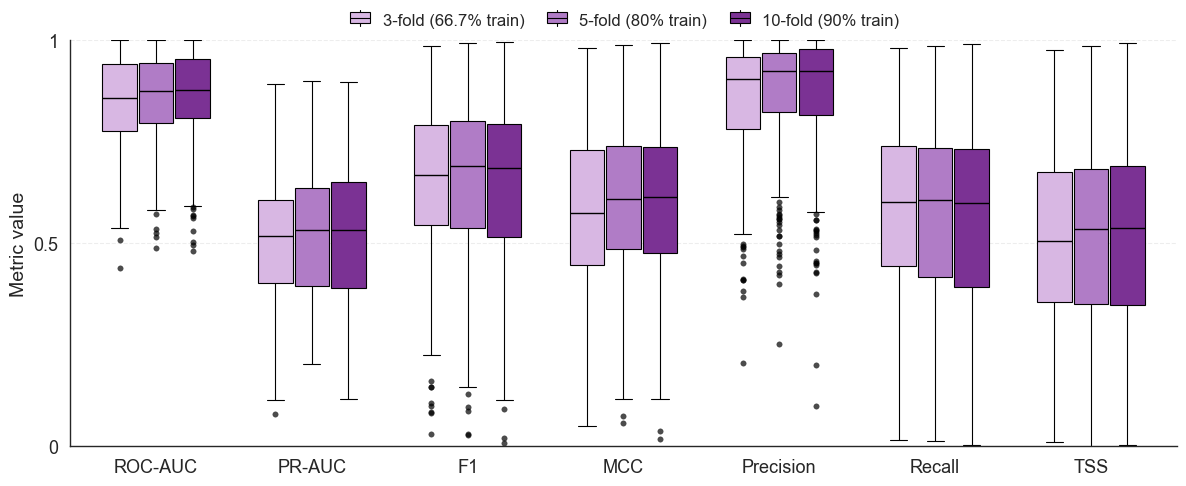

In [5]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_context("paper", font_scale=1.15)
sns.set_style("white")


# ============================================================
# Locate repository root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").exists() and (path / "docs").exists():
            return path

    raise RuntimeError(
        f"Could not locate repository root from: {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Input configuration
# ============================================================
RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const"
)

RETENTION_DIR = (
    RESULT_DIR
    / "retention_protocol"
    / "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

INPUT_PATH = (
    RETENTION_DIR
    / "figure_inputs"
    / "predictive_train10-90_after_tukey.csv"
)

MANIFEST_PATH = RETENTION_DIR / "retention_manifest.json"

OUT_DIR = RETENTION_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = (
    OUT_DIR
    / "predictive_metrics_wlnm_dir_neg_kfold_roleonly_threshold0p5_tukey_web_level.png"
)


# ============================================================
# Experimental configuration
# ============================================================
THRESHOLD_TARGET = 0.5
K_TARGET = 10

cvk_order = [3, 5, 10]

SHOW_WEB_LEVEL_FLIERS = True

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]


# ============================================================
# Helpers
# ============================================================
def cvk_label(k: int) -> str:
    train_ratio_map = {
        3: "66.7%",
        5: "80%",
        10: "90%",
    }

    if k in train_ratio_map:
        return f"{k}-fold ({train_ratio_map[k]} train)"

    return f"{k}-fold"


def validate_retention_manifest(manifest_path: Path) -> dict:
    if not manifest_path.is_file():
        raise FileNotFoundError(
            "Retention manifest not found:\n"
            f"  {manifest_path}"
        )

    with manifest_path.open("r", encoding="utf-8") as handle:
        manifest = json.load(handle)

    source_metadata = manifest.get("source_manifest", {})

    expected_metadata = {
        "Version": "WLNM_dir_neg_kfold",
        "Eligibility": "role_only",
        "MassEligibilityEnabled": "false",
        "ClassificationThreshold": "0.50",
        "NumExperimentsPerFold": "20",
        "TargetNegativePositiveRatio": "2",
        "CheckConnectivity": "false",
        "AdaptiveConnectivity": "false",
    }

    mismatches = []

    for key, expected_value in expected_metadata.items():
        actual_value = source_metadata.get(key)

        if (
            str(actual_value).strip().lower()
            != str(expected_value).strip().lower()
        ):
            mismatches.append(
                f"{key}: expected {expected_value!r}, "
                f"found {actual_value!r}"
            )

    if mismatches:
        raise ValueError(
            "The retention manifest does not match the expected "
            "role-only k-fold configuration:\n  "
            + "\n  ".join(mismatches)
        )

    print("[INFO] Retention manifest validated.")
    print("[INFO] Configuration: role-only eligibility.")
    print("[INFO] Classification threshold: 0.5.")
    print("[INFO] Repeated CV experiments per K: 20.")
    print("[INFO] Tukey filtering: 1.5×IQR per food web, K and metric.")

    return manifest


def load_tukey_web_level_metrics(input_path: Path):
    required_columns = {
        "Foodweb",
        "Version",
        "TrainRatio",
        "Threshold",
        "K",
        "CvK",
        "Metric",
        "MetricLabel",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
    }

    if not input_path.is_file():
        raise FileNotFoundError(
            "Tukey-filtered figure input not found:\n"
            f"  {input_path}"
        )

    print(f"[INFO] Using Tukey-filtered input:\n  {input_path}")

    df = pd.read_csv(input_path)

    missing_columns = sorted(required_columns.difference(df.columns))

    if missing_columns:
        raise ValueError(
            "The Tukey input is missing required columns:\n  "
            + "\n  ".join(missing_columns)
        )

    numeric_columns = [
        "TrainRatio",
        "Threshold",
        "K",
        "CvK",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # Keep only the intended predictive metrics.
    df = df.loc[
        df["MetricFamily"].astype(str).eq("predictive")
        & df["Metric"].isin(METRICS)
    ].copy()

    # Keep only the fixed classification threshold of 0.5.
    df = df.loc[
        np.isclose(
            df["Threshold"],
            THRESHOLD_TARGET,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    # Keep the expected WLNM subgraph parameter.
    if K_TARGET is not None:
        df = df.loc[df["K"].eq(K_TARGET)].copy()

    # Keep 3-, 5- and 10-fold results.
    df = df.loc[df["CvK"].isin(cvk_order)].copy()

    # Keep only food-web/metric groups satisfying MinRetainedRuns.
    df = df.loc[
        df["MeetsMinimumRetainedRuns"].eq(1)
        & df["MeanAfterTukey"].notna()
    ].copy()

    if df.empty:
        raise ValueError(
            "No Tukey-filtered observations remained after applying "
            "the required configuration."
        )

    df["CvK"] = df["CvK"].astype(int)

    duplicate_mask = df.duplicated(
        subset=["Foodweb", "CvK", "Metric"],
        keep=False,
    )

    if duplicate_mask.any():
        duplicate_rows = (
            df.loc[
                duplicate_mask,
                ["Foodweb", "CvK", "Metric"],
            ]
            .sort_values(["Foodweb", "CvK", "Metric"])
        )

        raise ValueError(
            "Duplicate food-web/CvK/metric rows were found:\n"
            f"{duplicate_rows.head(20).to_string(index=False)}"
        )

    # Validate expected coverage.
    coverage = (
        df.groupby(["CvK", "Metric"])["Foodweb"]
        .nunique()
        .unstack("Metric")
        .reindex(index=cvk_order, columns=METRICS)
    )

    print("\n[INFO] Retained food webs per CvK and metric:")
    display(coverage)

    incomplete_coverage = coverage.ne(290) | coverage.isna()

    if incomplete_coverage.any().any():
        failed = []

        for cvk in cvk_order:
            for metric in METRICS:
                observed = coverage.loc[cvk, metric]

                if pd.isna(observed) or int(observed) != 290:
                    failed.append(
                        f"CvK={cvk}, metric={metric}: "
                        f"{observed} food webs"
                    )

        raise ValueError(
            "Expected 290 retained food webs for every predictive "
            "metric and CvK:\n  "
            + "\n  ".join(failed)
        )

    # Each row currently represents one Tukey-filtered food-web mean
    # for one metric and one CvK.
    metric_values = (
        df.pivot(
            index=["Foodweb", "CvK"],
            columns="Metric",
            values="MeanAfterTukey",
        )
        .reset_index()
    )

    metric_values.columns.name = None

    # Keep experimental metadata and metric-specific retention counts.
    metadata = (
        df.groupby(
            ["Foodweb", "CvK"],
            as_index=False,
        )
        .agg(
            TrainRatio=("TrainRatio", "median"),
            K=("K", "median"),
            Threshold=("Threshold", "median"),
            MinRetainedRuns=(
                "RetainedRunsAfterTukey",
                "min",
            ),
            MedianRetainedRuns=(
                "RetainedRunsAfterTukey",
                "median",
            ),
            MaxRetainedRuns=(
                "RetainedRunsAfterTukey",
                "max",
            ),
        )
    )

    df_web = metadata.merge(
        metric_values,
        on=["Foodweb", "CvK"],
        how="inner",
        validate="one_to_one",
    )

    cvk_to_label = {
        k: cvk_label(k)
        for k in cvk_order
    }

    df_web["CvK_label"] = df_web["CvK"].map(cvk_to_label)

    missing_metric_values = df_web[METRICS].isna().sum()

    if missing_metric_values.any():
        raise ValueError(
            "Missing metric values after converting the Tukey input "
            "to web-level format:\n"
            f"{missing_metric_values[missing_metric_values > 0]}"
        )

    return df, df_web


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            whisker_top,
            whisker_bottom,
        ]


def plot_kfold_web_level_metrics(df_web: pd.DataFrame) -> None:
    if df_web.empty:
        print("No data to plot.")
        return

    present_cvks = [
        k
        for k in cvk_order
        if (df_web["CvK"] == k).any()
    ]

    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        k: cvk_label(k)
        for k in present_cvks
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.45
    group_centers = (
        1.0
        + np.arange(len(plot_metrics)) * group_gap
    )

    offsets = np.linspace(
        -0.34,
        0.34,
        len(present_cvks),
    )

    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []

        for i, (metric, _) in enumerate(plot_metrics):
            values = (
                df_web.loc[
                    df_web["CvK"] == cvk,
                    metric,
                ]
                .dropna()
                .values
            )

            if len(values) == 0:
                continue

            data_for_cvk.append(values)
            positions_for_cvk.append(
                group_centers[i] + offsets[j]
            )

        if not data_for_cvk:
            continue

        boxplot = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=SHOW_WEB_LEVEL_FLIERS,
            boxprops=dict(
                edgecolor="black",
                linewidth=0.8,
            ),
            medianprops=dict(
                color="black",
                linewidth=1.0,
            ),
            whiskerprops=dict(
                color="black",
                linewidth=0.8,
            ),
            capprops=dict(
                color="black",
                linewidth=0.8,
            ),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box in boxplot["boxes"]:
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(
        group_centers[0] - 0.8,
        group_centers[-1] + 0.8,
    )

    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [label for _, label in plot_metrics],
        ha="center",
        fontsize=13,
    )

    ax.set_ylabel(
        "Metric value",
        fontsize=14,
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="y",
        labelsize=13,
    )

    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.35,
    )

    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[
            label_map[k]
            for k in present_cvks
        ],
        handler_map={
            dict: HandlerMiniBoxplot()
        },
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(present_cvks),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
        columnspacing=1.2,
    )

    plt.tight_layout()

    fig.savefig(
        OUT_PATH,
        dpi=300,
        bbox_inches="tight",
    )

    print(f"[INFO] Saved figure: {OUT_PATH}")

    plt.show()


# ============================================================
# Run
# ============================================================
manifest = validate_retention_manifest(MANIFEST_PATH)

df_retained, df_web = load_tukey_web_level_metrics(
    INPUT_PATH
)

print("\n[INFO] Tukey-filtered metric-level shape:")
print(df_retained.shape)

print("\n[INFO] Web-level shape:")
print(df_web.shape)

print("\n[INFO] Food-web count per CvK:")
print(
    df_web.groupby("CvK")["Foodweb"]
    .nunique()
)

retention_summary = (
    df_retained
    .groupby("CvK")
    .agg(
        FoodWebs=("Foodweb", "nunique"),
        Metrics=("Metric", "nunique"),
        TrainRatio=("TrainRatio", "median"),
        Threshold=("Threshold", "median"),
        MinimumRetained=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetained=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetained=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
    .reset_index()
)

print("\n[INFO] Tukey retention summary:")
display(retention_summary)

summary_rows = []

for cvk in cvk_order:
    for metric, metric_label in plot_metrics:
        values = (
            df_web.loc[
                df_web["CvK"] == cvk,
                metric,
            ]
            .dropna()
        )

        if values.empty:
            continue

        summary_rows.append(
            {
                "CvK": cvk,
                "Label": cvk_label(cvk),
                "Metric": metric_label,
                "N food webs": int(values.shape[0]),
                "Mean": values.mean(),
                "Median": values.median(),
                "SD": values.std(ddof=1),
                "Variance": values.var(ddof=1),
            }
        )

summary_table = pd.DataFrame(summary_rows)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[column] = (
        summary_table[column]
        .round(4)
    )

print(
    "\n=== Web-level k-fold predictive metric summary "
    "after Tukey filtering at threshold 0.5 ==="
)

display(summary_table)

plot_kfold_web_level_metrics(df_web)

[INFO] Validated final role-only configuration:
  scenario=role_only_5_role_constraints_checkconnfalse_adaptivefalse_threshold0p50
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_role_pool_then_uniform_remaining_nonlinks_topup
  target_negative_positive_ratio=2
  classification_threshold=0.50
  check_connectivity=false
  adaptive_connectivity=false
  number_of_experiments=50
  train_ratio_range=0.10:0.10:0.90
  retention_protocol=tukey_iqr_1p5_min50pct_threshold0p50_v1
[INFO] Filtered food webs by size: kept 290 / 290 (>= 0 nodes).

[INFO] Retained metric-food-web observations:
Total rows: 2,030
Rows per ecosystem:
EcosystemType
lakes                      385
marine                     938
streams                    196
terrestrial aboveground    147
terrestrial belowground    364
dtype: int64

[INFO] Web-level observations after Tukey filtering:
Total web-level rows: 290


,EcosystemType,FoodWebs,MinRunsAveraged,MedianRunsAveraged,MaxRunsAveraged
0,lakes,55,36,42.0,50
1,marine,134,31,46.0,50
2,streams,28,35,43.5,50
3,terrestrial aboveground,21,38,47.0,50
4,terrestrial belowground,52,42,48.0,50



=== Web-level precision median and variance by ecosystem ===


,EcosystemType,n_foodwebs,Precision_Median,Precision_Variance
0,lakes,55,1.0000,0.010063
1,marine,134,0.9681,0.021227
2,streams,28,1.0000,0.085913
3,terrestrial aboveground,21,0.9216,0.012816
4,terrestrial belowground,52,0.8806,0.003956



=== Ecosystems with lowest/highest median precision and variance ===
Lowest median precision:  terrestrial belowground (median = 0.8806, variance = 0.003956, n_foodwebs = 52)
Highest median precision: lakes (median = 1.0, variance = 0.010063, n_foodwebs = 55)
Lowest variance:          terrestrial belowground (variance = 0.003956, median = 0.8806, n_foodwebs = 52)
Highest variance:         streams (variance = 0.085913, median = 1.0, n_foodwebs = 28)
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/predictive_metrics_wlnm_dir_neg_train90_by_ecosystem_roleonly_5constraints_checkconnfalse_adaptivefalse_threshold0p50_tukey_filtered.png
[INFO] Configuration: eligibility=role_only, mass_constraint=False, random_topup=True, negative_positive_ratio=2:1, check_connectivity=False, adaptive_connectivity=False, classific

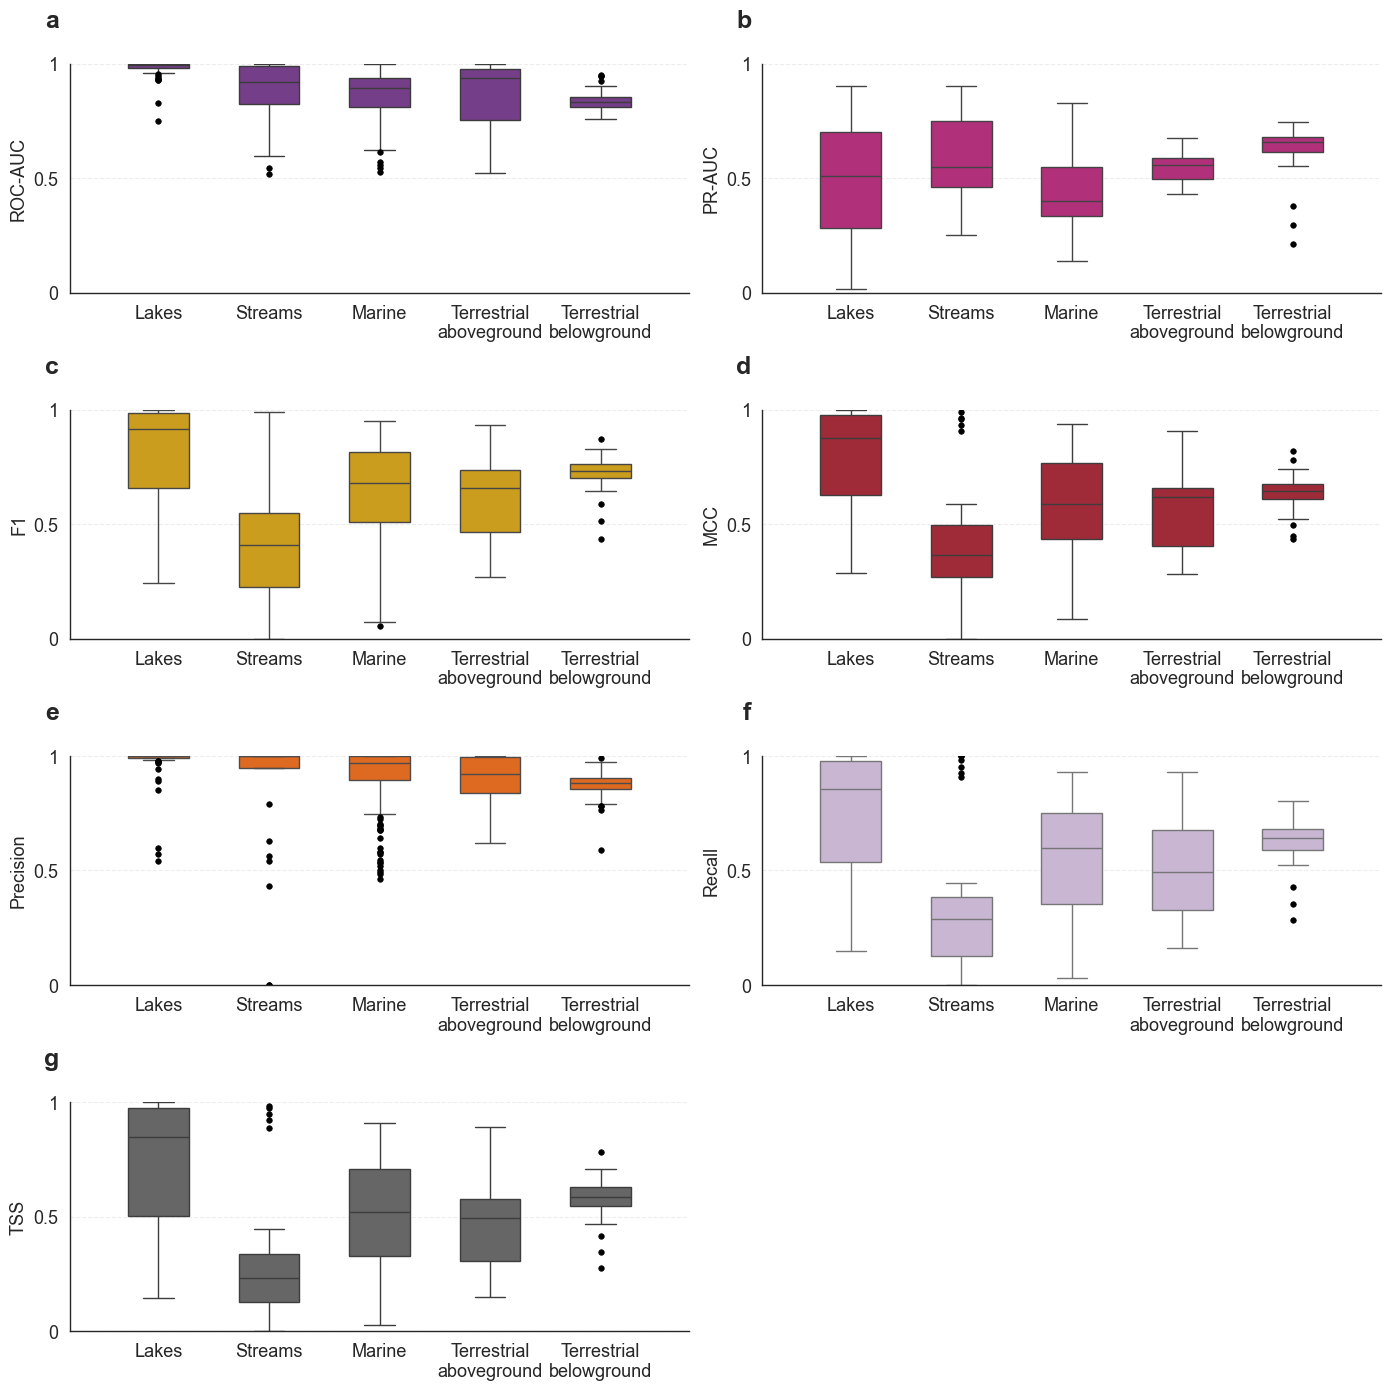

In [4]:
import json
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display


sns.set_context("paper")
sns.set_style("white")


# ============================================================
# Locate repo root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for path in [start, *start.parents]:
        if (
            (path / "src/matlab").exists()
            and (path / "docs").exists()
        ):
            return path

    raise RuntimeError(
        f"Could not locate repo root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only configuration
# ============================================================

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

MIN_NODES = 0
TRAIN_RATIO_TARGET = 90

SHOW_WEB_LEVEL_FLIERS = True

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "role_only_5_role_constraints_"
    "checkconnfalse_adaptivefalse_threshold0p50"
)


# ============================================================
# Final role-only input data
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

PREDICTIVE_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / (
        f"predictive_train{TRAIN_RATIO_TARGET}"
        "_after_tukey.csv"
    )
)

RETENTION_MANIFEST = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

ECOSYSTEM_FILE = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUT_PATH = (
    OUT_DIR
    / (
        "predictive_metrics_wlnm_dir_neg_"
        f"train{TRAIN_RATIO_TARGET}_by_ecosystem_"
        "roleonly_5constraints_"
        "checkconnfalse_adaptivefalse_"
        "threshold0p50_tukey_filtered.png"
    )
)


# ============================================================
# Metrics — original order, labels and colours preserved
# ============================================================

METRIC_ORDER = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

xtick_labels = [
    "ROC-AUC",
    "PR-AUC",
    "F1",
    "MCC",
    "Precision",
    "Recall",
    "TSS",
]

metric_palette = {
    "ROC_AUC": "#7B3294",
    "PR_AUC": "#C51B7D",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "F1Score": "#E6AB02",
    "TestMCC": "#B2182B",
    "TestTSS": "#666666",
    "TestTPR": "#1B9E77",
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
    "TestTPR": "TPR",
}


# ============================================================
# Validate inputs
# ============================================================

required_files = {
    "Tukey-filtered predictive input": PREDICTIVE_INPUT,
    "Ecosystem metadata": ECOSYSTEM_FILE,
    "Tukey retention manifest": RETENTION_MANIFEST,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_files)
    )


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST.open(
    "r",
    encoding="utf-8",
) as handle:
    retention_manifest = json.load(handle)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Condition": EXPECTED_SCENARIO,
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": (
        "uniform_role_pool_then_uniform_remaining_nonlinks_topup"
    ),
    "TargetNegativePositiveRatio": "2",
    "NumExperiments": "50",
    "TrainRatioRange": "0.10:0.10:0.90",
    "ClassificationThreshold": "0.50",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(key)

    if observed_value is None:
        configuration_errors.append(
            f"{key}: missing"
        )
    elif (
        str(observed_value).casefold()
        != str(expected_value).casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected_value}, "
            f"found {observed_value}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the "
        "final role-only configuration:\n\n"
        + "\n".join(configuration_errors)
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if (
    observed_threshold is None
    or not np.isclose(
        float(observed_threshold),
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
    )
):
    raise ValueError(
        "The retention protocol does not use "
        f"classification threshold {CLASSIFICATION_THRESHOLD:.2f}."
    )

print("[INFO] Validated final role-only configuration:")
print(f"  scenario={manifest['Condition']}")
print(f"  eligibility={manifest['Eligibility']}")
print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)
print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)
print(
    "  target_negative_positive_ratio="
    f"{manifest['TargetNegativePositiveRatio']}"
)
print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)
print(
    "  check_connectivity="
    f"{manifest['CheckConnectivity']}"
)
print(
    "  adaptive_connectivity="
    f"{manifest['AdaptiveConnectivity']}"
)
print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)
print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)
print(f"  retention_protocol={PROTOCOL_NAME}")


# ============================================================
# Normalisation helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(
    ECOSYSTEM_FILE
)

node_candidates = {
    "nnodes",
    "numnodes",
    "nodes",
    "nodecount",
    "n",
    "s",
}

norm_map = {
    normalize_colname(column): column
    for column in df_ecosystem.columns
}

node_col = next(
    (
        norm_map[candidate]
        for candidate in node_candidates
        if candidate in norm_map
    ),
    None,
)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in "
        "ecosystem metadata."
    )

if (
    "Foodweb" not in df_ecosystem.columns
    or "EcosystemType" not in df_ecosystem.columns
):
    raise RuntimeError(
        "The ecosystem metadata must contain Foodweb "
        "and EcosystemType."
    )

df_ecosystem[node_col] = pd.to_numeric(
    df_ecosystem[node_col],
    errors="coerce",
)

df_ecosystem["FW_KEY"] = (
    df_ecosystem["Foodweb"]
    .apply(normalize_foodweb)
)

duplicated_metadata = df_ecosystem.duplicated(
    subset=["FW_KEY"],
    keep=False,
)

if duplicated_metadata.any():
    inconsistent_metadata = (
        df_ecosystem.loc[
            duplicated_metadata,
            [
                "FW_KEY",
                "EcosystemType",
                node_col,
            ],
        ]
        .groupby("FW_KEY")
        .nunique(
            dropna=False
        )
    )

    inconsistent_metadata = inconsistent_metadata[
        (
            inconsistent_metadata[
                "EcosystemType"
            ] > 1
        )
        | (
            inconsistent_metadata[
                node_col
            ] > 1
        )
    ]

    if not inconsistent_metadata.empty:
        display(inconsistent_metadata)

        raise ValueError(
            "Conflicting metadata were found for one "
            "or more normalised food-web names."
        )

metadata_for_merge = (
    df_ecosystem[
        [
            "FW_KEY",
            "EcosystemType",
            node_col,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"],
        keep="first",
    )
)


# ============================================================
# Load final role-only Tukey-filtered predictive data
# ============================================================

predictive = pd.read_csv(
    PREDICTIVE_INPUT
)

required_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_columns = sorted(
    required_columns.difference(
        predictive.columns
    )
)

if missing_columns:
    raise ValueError(
        "The predictive Tukey input is missing columns:\n  "
        + "\n  ".join(missing_columns)
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    predictive[column] = pd.to_numeric(
        predictive[column],
        errors="coerce",
    )


# ============================================================
# Select requested role-only configuration
# ============================================================

predictive = predictive.loc[
    predictive["Scenario"].eq(
        EXPECTED_SCENARIO
    )
    & predictive["Version"].eq(
        "WLNM_dir_neg"
    )
    & (
        predictive["MetricFamily"]
        .astype(str)
        .str.casefold()
        .eq("predictive")
    )
    & predictive["Metric"].isin(
        METRIC_ORDER
    )
    & np.isclose(
        predictive["TrainRatio"],
        TRAIN_RATIO_TARGET,
        atol=1e-9,
        equal_nan=False,
    )
    & np.isclose(
        predictive["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
    & predictive[
        "MeetsMinimumRetainedRuns"
    ].eq(1)
    & predictive[
        "MeanAfterTukey"
    ].notna()
].copy()

if predictive.empty:
    raise RuntimeError(
        "No retained final role-only predictive results "
        "were found for "
        f"TrainRatio={TRAIN_RATIO_TARGET} and "
        f"Threshold={CLASSIFICATION_THRESHOLD:.2f}."
    )

predictive["FW_KEY"] = (
    predictive["Foodweb"]
    .apply(normalize_foodweb)
)

duplicated_rows = predictive.duplicated(
    subset=[
        "FW_KEY",
        "Metric",
    ],
    keep=False,
)

if duplicated_rows.any():
    duplicated = (
        predictive.loc[
            duplicated_rows,
            [
                "Foodweb",
                "Metric",
                "TrainRatio",
                "Threshold",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "Foodweb",
            ]
        )
    )

    display(duplicated)

    raise ValueError(
        "More than one retained row was found per "
        "food web and metric."
    )


# ============================================================
# Merge with ecosystem metadata
# ============================================================

predictive = predictive.merge(
    metadata_for_merge,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_ecosystem = (
    predictive["EcosystemType"].isna()
)

if missing_ecosystem.any():
    missing_foodwebs = sorted(
        predictive.loc[
            missing_ecosystem,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem metadata could not be matched for "
        f"{len(missing_foodwebs)} food webs:\n  "
        + "\n  ".join(
            missing_foodwebs[:30]
        )
    )


# ============================================================
# Apply node-count filter
# ============================================================

before_n = (
    predictive["FW_KEY"]
    .nunique()
)

predictive = predictive.loc[
    predictive[node_col]
    .ge(MIN_NODES)
].copy()

after_n = (
    predictive["FW_KEY"]
    .nunique()
)

print(
    f"[INFO] Filtered food webs by size: "
    f"kept {after_n} / {before_n} "
    f"(>= {MIN_NODES} nodes)."
)

if predictive.empty:
    raise ValueError(
        f"No food webs left after filtering "
        f"Nodes >= {MIN_NODES}."
    )

print(
    "\n[INFO] Retained metric-food-web observations:"
)

print(
    f"Total rows: {len(predictive):,}"
)

print(
    "Rows per ecosystem:"
)

print(
    predictive
    .groupby("EcosystemType")
    .size()
)


# ============================================================
# Adapt input to original web-level structure
# ============================================================

metric_values = (
    predictive
    .pivot(
        index=[
            "Foodweb",
            "FW_KEY",
            "EcosystemType",
            node_col,
        ],
        columns="Metric",
        values="MeanAfterTukey",
    )
    .reset_index()
)

metric_values.columns.name = None

missing_metrics = [
    metric
    for metric in METRIC_ORDER
    if metric not in metric_values.columns
]

if missing_metrics:
    raise ValueError(
        "The following predictive metrics are missing "
        "after pivoting:\n  "
        + "\n  ".join(missing_metrics)
    )

retention_by_web = (
    predictive
    .groupby(
        [
            "Foodweb",
            "FW_KEY",
        ],
        as_index=False,
    )
    .agg(
        RunsAveraged=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MaximumRunsAveraged=(
            "RetainedRunsAfterTukey",
            "max",
        ),
        TotalOutlierRunsExcluded=(
            "OutlierRunsExcluded",
            "sum",
        ),
    )
)

df_web = metric_values.merge(
    retention_by_web,
    on=[
        "Foodweb",
        "FW_KEY",
    ],
    how="left",
    validate="one_to_one",
)

print(
    "\n[INFO] Web-level observations after "
    "Tukey filtering:"
)

print(
    f"Total web-level rows: "
    f"{len(df_web):,}"
)

display(
    df_web
    .groupby("EcosystemType")
    .agg(
        FoodWebs=(
            "Foodweb",
            "nunique",
        ),
        MinRunsAveraged=(
            "RunsAveraged",
            "min",
        ),
        MedianRunsAveraged=(
            "RunsAveraged",
            "median",
        ),
        MaxRunsAveraged=(
            "MaximumRunsAveraged",
            "max",
        ),
    )
    .reset_index()
)


# ============================================================
# Precision summary by ecosystem, web-level
# ============================================================

precision_summary = (
    df_web
    .dropna(
        subset=[
            "EcosystemType",
            "Precision",
        ]
    )
    .groupby(
        "EcosystemType",
        as_index=False,
    )
    .agg(
        n_foodwebs=(
            "Foodweb",
            "nunique",
        ),
        Precision_Median=(
            "Precision",
            "median",
        ),
        Precision_Variance=(
            "Precision",
            lambda values: values.var(
                ddof=1
            ),
        ),
    )
)

precision_summary[
    "Precision_Median"
] = precision_summary[
    "Precision_Median"
].round(4)

precision_summary[
    "Precision_Variance"
] = precision_summary[
    "Precision_Variance"
].round(6)

print(
    "\n=== Web-level precision median and "
    "variance by ecosystem ==="
)

display(
    precision_summary
)

lowest_precision = precision_summary.loc[
    precision_summary[
        "Precision_Median"
    ].idxmin()
]

highest_precision = precision_summary.loc[
    precision_summary[
        "Precision_Median"
    ].idxmax()
]

lowest_variance = precision_summary.loc[
    precision_summary[
        "Precision_Variance"
    ].idxmin()
]

highest_variance = precision_summary.loc[
    precision_summary[
        "Precision_Variance"
    ].idxmax()
]

print(
    "\n=== Ecosystems with lowest/highest "
    "median precision and variance ==="
)

print(
    f"Lowest median precision:  "
    f"{lowest_precision['EcosystemType']} "
    f"(median = "
    f"{lowest_precision['Precision_Median']}, "
    f"variance = "
    f"{lowest_precision['Precision_Variance']}, "
    f"n_foodwebs = "
    f"{lowest_precision['n_foodwebs']})"
)

print(
    f"Highest median precision: "
    f"{highest_precision['EcosystemType']} "
    f"(median = "
    f"{highest_precision['Precision_Median']}, "
    f"variance = "
    f"{highest_precision['Precision_Variance']}, "
    f"n_foodwebs = "
    f"{highest_precision['n_foodwebs']})"
)

print(
    f"Lowest variance:          "
    f"{lowest_variance['EcosystemType']} "
    f"(variance = "
    f"{lowest_variance['Precision_Variance']}, "
    f"median = "
    f"{lowest_variance['Precision_Median']}, "
    f"n_foodwebs = "
    f"{lowest_variance['n_foodwebs']})"
)

print(
    f"Highest variance:         "
    f"{highest_variance['EcosystemType']} "
    f"(variance = "
    f"{highest_variance['Precision_Variance']}, "
    f"median = "
    f"{highest_variance['Precision_Median']}, "
    f"n_foodwebs = "
    f"{highest_variance['n_foodwebs']})"
)


# ============================================================
# Prepare long-format web-level data
# ============================================================

df_plot = df_web.melt(
    id_vars=[
        "Foodweb",
        "EcosystemType",
        "RunsAveraged",
    ],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value",
)


# ============================================================
# Preferred ecosystem order — preserved
# ============================================================

preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_web["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {
    ecosystem.lower(): ecosystem
    for ecosystem in ecosystems_present
}

ecosystem_order = [
    eco_lookup[ecosystem]
    for ecosystem
    in preferred_ecosystem_order
    if ecosystem in eco_lookup
]

ecosystem_order += [
    ecosystem
    for ecosystem
    in ecosystems_present
    if ecosystem.lower()
    not in set(
        preferred_ecosystem_order
    )
]


# ============================================================
# Labels — preserved
# ============================================================

labels_map = (
    df_web[
        [
            "Foodweb",
            "EcosystemType",
        ]
    ]
    .drop_duplicates()
    .groupby("EcosystemType")[
        "Foodweb"
    ]
    .nunique()
    .to_dict()
)


def format_ecosystem_label(
    ecosystem,
    number_foodwebs,
):
    ecosystem_clean = str(
        ecosystem
    ).strip()

    ecosystem_lower = (
        ecosystem_clean.lower()
    )

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": (
            "Terrestrial\naboveground"
        ),
        "terrestrial belowground": (
            "Terrestrial\nbelowground"
        ),
    }

    return label_replacements.get(
        ecosystem_lower,
        ecosystem_clean.capitalize(),
    )


labels_map = {
    ecosystem: format_ecosystem_label(
        ecosystem,
        number_foodwebs,
    )
    for ecosystem, number_foodwebs
    in labels_map.items()
}

subset = df_plot.copy()

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)


# ============================================================
# Plot — styling preserved
# ============================================================

n_panels = len(
    METRIC_ORDER
)

n_cols = 2

n_rows = math.ceil(
    n_panels / n_cols
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14),
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

for index, metric in enumerate(
    METRIC_ORDER
):
    ax = axes[index]

    sub = subset[
        subset["Metric"]
        == metric
    ].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(
            metric,
            "#7B3294",
        ),
        width=0.55,
        showfliers=(
            SHOW_WEB_LEVEL_FLIERS
        ),
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    legend = ax.get_legend()

    if legend is not None:
        legend.remove()

    ax.set_xlabel("")

    ax.set_xticks(
        range(
            len(ecosystem_order)
        )
    )

    ax.set_xticklabels(
        [
            labels_map.get(
                ecosystem,
                ecosystem,
            )
            for ecosystem
            in ecosystem_order
        ],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1,
    )

    ax.set_ylabel(
        metric_label_map.get(
            metric,
            metric,
        ),
        fontsize=13,
    )

    ax.tick_params(
        axis="y",
        labelsize=13,
    )

    ax.set_yticks([
        0,
        0.5,
        1.0,
    ])

    ax.set_yticklabels([
        "0",
        "0.5",
        "1",
    ])

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.35,
    )

    ax.set_xlim(
        -0.8,
        len(ecosystem_order)
        - 1
        + 0.8,
    )

    ax.set_ylim(
        0,
        1.0,
    )

    ax.grid(
        False,
        axis="x",
    )

    sns.despine(
        ax=ax
    )

    ax.annotate(
        panel_letters[index],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for panel_index in range(
    n_panels,
    len(axes),
):
    axes[
        panel_index
    ].set_axis_off()

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        1,
    ],
    w_pad=1,
    h_pad=1,
)

fig.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"[INFO] Saved figure: "
    f"{OUT_PATH}"
)

print(
    "[INFO] Configuration: "
    "eligibility=role_only, "
    "mass_constraint=False, "
    "random_topup=True, "
    "negative_positive_ratio=2:1, "
    "check_connectivity=False, "
    "adaptive_connectivity=False, "
    "classification_threshold=0.50, "
    f"train_ratio={TRAIN_RATIO_TARGET}."
)

plt.show()

[INFO] Validated final role-only configuration:
  scenario=role_only_5_role_constraints_checkconnfalse_adaptivefalse_threshold0p50
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_role_pool_then_uniform_remaining_nonlinks_topup
  target_negative_positive_ratio=2
  classification_threshold=0.50
  check_connectivity=false
  adaptive_connectivity=false
  number_of_experiments=50
  train_ratio_range=0.10:0.10:0.90
  retention_protocol=tukey_iqr_1p5_min50pct_threshold0p50_v1
Filtered data: TrainRatio = 90.0, Threshold = 0.50, Nodes >= 0. Rows kept: 290 / 290. Food webs kept: 290 / 290.
[INFO] Using final role-only Tukey-filtered food-web means.
[INFO] Configuration: eligibility=role_only, mass_constraint=False, random_topup=True, negative_positive_ratio=2:1, check_connectivity=False, adaptive_connectivity=False, classification_threshold=0.50, train_ratio=90.

=== OLS linear regression: metric ~ number of nodes ===
a) ROC-AUC: y = 0.917971 - 0.000607x; F1,

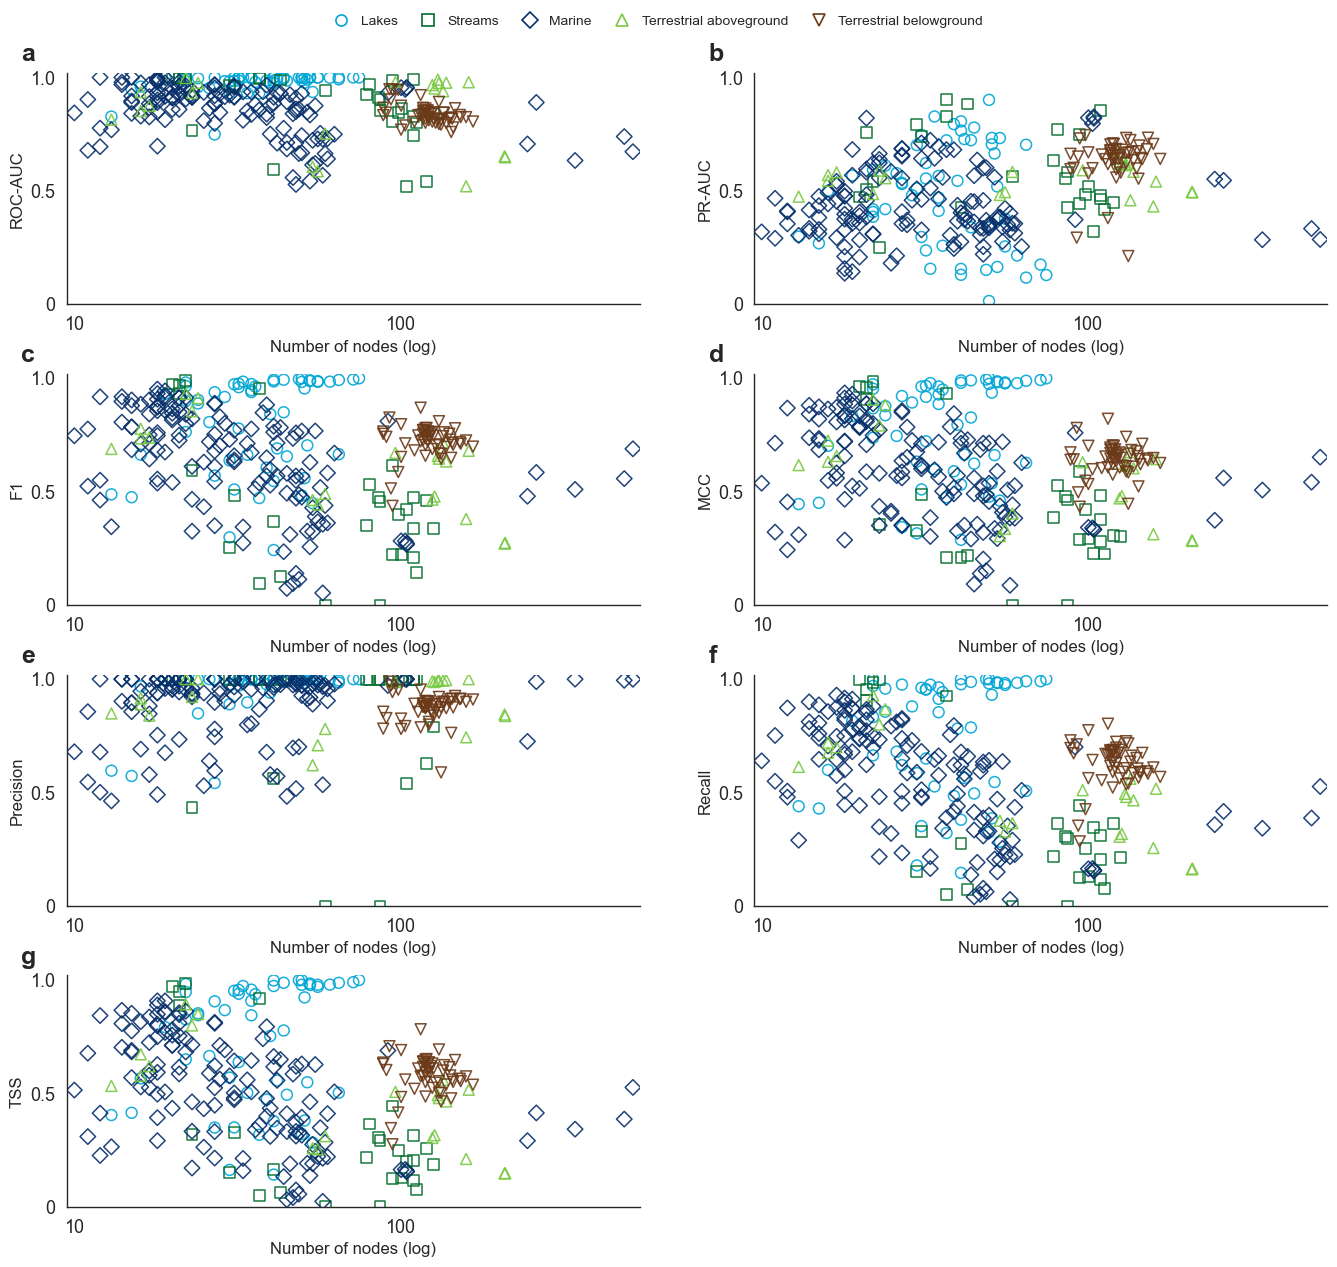

In [5]:
import os
import json
import math
import tempfile

from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(
        Path(tempfile.gettempdir())
        / "qmul_phd_framework_mplconfig"
    ),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter


sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for candidate in [
        start,
        *start.parents,
    ]:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        f"Could not locate repository root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final role-only configuration
# ============================================================

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

TARGET_RATIO = 90.0
MIN_NODES = 0

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "role_only_5_role_constraints_"
    "checkconnfalse_adaptivefalse_threshold0p50"
)

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

PREDICTIVE_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / (
        f"predictive_train{int(TARGET_RATIO)}"
        "_after_tukey.csv"
    )
)

RETENTION_MANIFEST = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

ECOSYSTEM_FILE = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Figure configuration — preserved
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
X_MAX = 550
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


def find_column(
    dataframe,
    candidates,
):
    norm_map = {
        normalize_colname(column): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        normalized_candidate = normalize_colname(
            candidate
        )

        if normalized_candidate in norm_map:
            return norm_map[
                normalized_candidate
            ]

    raise KeyError(
        "Could not find any of these columns: "
        f"{candidates}"
    )


def normalize_train_ratio(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    return np.where(
        values <= 1.0,
        values * 100.0,
        values,
    )


def format_ecosystem_label(name):
    name = str(
        name
    ).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": (
            "Terrestrial aboveground"
        ),
        "terrestrial belowground": (
            "Terrestrial belowground"
        ),
        "unknown": "Unknown",
    }

    return label_map.get(
        name,
        str(name).strip().capitalize(),
    )


def format_p_value(p_value):
    if pd.isna(p_value):
        return "P = NA"

    if p_value < 0.0001:
        return "P < 0.0001"

    return f"P = {p_value:.4f}"


def format_equation(
    intercept,
    slope,
):
    sign = (
        "+"
        if slope >= 0
        else "-"
    )

    return (
        f"y = {intercept:.6f} "
        f"{sign} {abs(slope):.6f}x"
    )


# ============================================================
# Regression helper — preserved
# ============================================================

def fit_linear_regression(
    data,
    x_col,
    y_col,
    n_points=100,
):
    """
    Fits an OLS linear regression:

        y_col ~ x_col

    For this figure:
        metric ~ Nodes
    """
    work = (
        data[
            [
                x_col,
                y_col,
            ]
        ]
        .dropna()
        .copy()
    )

    if work.empty:
        return None

    work[x_col] = (
        work[x_col]
        .astype(float)
    )

    work[y_col] = (
        work[y_col]
        .astype(float)
    )

    if (
        len(work) < 3
        or work[x_col].nunique() < 2
    ):
        return None

    x = work[
        [x_col]
    ]

    y = work[
        y_col
    ]

    x_model = sm.add_constant(
        x,
        has_constant="add",
    )

    model = sm.OLS(
        y,
        x_model,
    ).fit()

    intercept = model.params[
        "const"
    ]

    slope = model.params[
        x_col
    ]

    x_line = np.linspace(
        work[x_col].min(),
        work[x_col].max(),
        n_points,
    )

    x_line_model = pd.DataFrame({
        x_col: x_line
    })

    x_line_model = sm.add_constant(
        x_line_model,
        has_constant="add",
    )

    y_line = model.predict(
        x_line_model
    )

    return {
        "x_line": x_line,
        "y_line": y_line,
        "intercept": intercept,
        "slope": slope,
        "f_value": model.fvalue,
        "df_model": int(
            model.df_model
        ),
        "df_resid": int(
            model.df_resid
        ),
        "p_value": model.pvalues[
            x_col
        ],
        "r_squared": model.rsquared,
        "n": len(work),
        "model": model,
    }


# ============================================================
# Validate selected inputs
# ============================================================

required_files = {
    "Tukey-filtered predictive input": (
        PREDICTIVE_INPUT
    ),
    "Ecosystem metadata": (
        ECOSYSTEM_FILE
    ),
    "Tukey retention manifest": (
        RETENTION_MANIFEST
    ),
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n\n"
        + "\n\n".join(
            missing_files
        )
    )


# ============================================================
# Validate final role-only result configuration
# ============================================================

with RETENTION_MANIFEST.open(
    "r",
    encoding="utf-8",
) as handle:
    retention_manifest = json.load(handle)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Condition": EXPECTED_SCENARIO,
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": (
        "uniform_role_pool_then_uniform_remaining_nonlinks_topup"
    ),
    "TargetNegativePositiveRatio": "2",
    "NumExperiments": "50",
    "TrainRatioRange": "0.10:0.10:0.90",
    "ClassificationThreshold": "0.50",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(
        key
    )

    if observed_value is None:
        configuration_errors.append(
            f"{key}: missing"
        )
    elif (
        str(observed_value).casefold()
        != str(expected_value).casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected_value}, "
            f"found {observed_value}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result directory does not match "
        "the final role-only configuration:\n\n"
        + "\n".join(
            configuration_errors
        )
    )

observed_scenario = retention_manifest.get(
    "scenario"
)

if observed_scenario != EXPECTED_SCENARIO:
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: {observed_scenario}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if (
    observed_threshold is None
    or not np.isclose(
        float(observed_threshold),
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
    )
):
    raise ValueError(
        "The Tukey retention protocol does not use "
        f"classification threshold "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

print("[INFO] Validated final role-only configuration:")
print(f"  scenario={manifest['Condition']}")
print(f"  eligibility={manifest['Eligibility']}")
print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)
print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)
print(
    "  target_negative_positive_ratio="
    f"{manifest['TargetNegativePositiveRatio']}"
)
print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)
print(
    "  check_connectivity="
    f"{manifest['CheckConnectivity']}"
)
print(
    "  adaptive_connectivity="
    f"{manifest['AdaptiveConnectivity']}"
)
print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)
print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)
print(f"  retention_protocol={PROTOCOL_NAME}")


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(
    ECOSYSTEM_FILE
).copy()

foodweb_col = find_column(
    df_ecosystem,
    [
        "foodweb",
    ],
)

ecosystem_col = find_column(
    df_ecosystem,
    [
        "ecosystemtype",
        "ecosystem",
        "ecosystem_type",
    ],
)

nodes_col = find_column(
    df_ecosystem,
    [
        "nodes",
        "n_nodes",
        "num_nodes",
        "nodecount",
        "s",
    ],
)

df_ecosystem = (
    df_ecosystem.rename(
        columns={
            foodweb_col: (
                "MetadataFoodweb"
            ),
            ecosystem_col: (
                "EcosystemType"
            ),
            nodes_col: (
                "Nodes"
            ),
        }
    )
)

df_ecosystem = (
    df_ecosystem[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
        ]
    ]
    .copy()
)

df_ecosystem[
    "MetadataFoodweb"
] = df_ecosystem[
    "MetadataFoodweb"
].astype(str)

df_ecosystem[
    "FoodwebKey"
] = df_ecosystem[
    "MetadataFoodweb"
].apply(
    normalize_foodweb_name
)

df_ecosystem[
    "EcosystemType"
] = (
    df_ecosystem[
        "EcosystemType"
    ]
    .astype(str)
    .str.strip()
)

df_ecosystem[
    "Nodes"
] = pd.to_numeric(
    df_ecosystem[
        "Nodes"
    ],
    errors="coerce",
)

duplicate_metadata = df_ecosystem.duplicated(
    subset=["FoodwebKey"],
    keep=False,
)

if duplicate_metadata.any():
    conflicting_metadata = (
        df_ecosystem.loc[
            duplicate_metadata,
            [
                "FoodwebKey",
                "EcosystemType",
                "Nodes",
            ],
        ]
        .groupby("FoodwebKey")
        .nunique(
            dropna=False
        )
    )

    conflicting_metadata = conflicting_metadata[
        (
            conflicting_metadata[
                "EcosystemType"
            ] > 1
        )
        | (
            conflicting_metadata[
                "Nodes"
            ] > 1
        )
    ]

    if not conflicting_metadata.empty:
        print(conflicting_metadata)

        raise ValueError(
            "Conflicting ecosystem or node metadata "
            "were found for one or more food webs."
        )

df_ecosystem = (
    df_ecosystem
    .drop_duplicates(
        subset=[
            "FoodwebKey",
        ],
        keep="first",
    )
    .copy()
)


# ============================================================
# Load final role-only Tukey-filtered results
# ============================================================

tukey_results = pd.read_csv(
    PREDICTIVE_INPUT
).copy()

required_columns = {
    "Scenario",
    "Foodweb",
    "Version",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_columns = sorted(
    required_columns.difference(
        tukey_results.columns
    )
)

if missing_columns:
    raise ValueError(
        "The Tukey-filtered input is missing columns:\n  "
        + "\n  ".join(
            missing_columns
        )
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    tukey_results[column] = pd.to_numeric(
        tukey_results[column],
        errors="coerce",
    )

tukey_results[
    "TrainRatio"
] = normalize_train_ratio(
    tukey_results[
        "TrainRatio"
    ]
)

metric_columns = [
    metric_column
    for metric_column, _
    in METRIC_SPECS
]

tukey_results = tukey_results.loc[
    tukey_results[
        "Scenario"
    ].eq(
        EXPECTED_SCENARIO
    )
    & tukey_results[
        "Version"
    ].eq(
        "WLNM_dir_neg"
    )
    & (
        tukey_results[
            "MetricFamily"
        ]
        .astype(str)
        .str.casefold()
        .eq("predictive")
    )
    & tukey_results[
        "Metric"
    ].isin(
        metric_columns
    )
    & np.isclose(
        tukey_results[
            "TrainRatio"
        ],
        TARGET_RATIO,
        atol=1e-9,
        equal_nan=False,
    )
    & np.isclose(
        tukey_results[
            "Threshold"
        ],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
    & tukey_results[
        "MeetsMinimumRetainedRuns"
    ].eq(1)
    & tukey_results[
        "MeanAfterTukey"
    ].notna()
].copy()

if tukey_results.empty:
    raise RuntimeError(
        "No retained final role-only results were found "
        f"for TrainRatio={TARGET_RATIO}, "
        f"Threshold={CLASSIFICATION_THRESHOLD:.2f}."
    )

tukey_results[
    "FoodwebKey"
] = tukey_results[
    "Foodweb"
].apply(
    normalize_foodweb_name
)

duplicate_groups = (
    tukey_results
    .duplicated(
        subset=[
            "FoodwebKey",
            "Metric",
        ],
        keep=False,
    )
)

if duplicate_groups.any():
    duplicated = (
        tukey_results.loc[
            duplicate_groups,
            [
                "Foodweb",
                "Metric",
                "TrainRatio",
                "Threshold",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "Foodweb",
            ]
        )
    )

    print(duplicated)

    raise ValueError(
        "More than one retained row was found per "
        "food web and metric."
    )


# ============================================================
# Convert metric rows to original wide format
# ============================================================

df_all = (
    tukey_results
    .pivot(
        index=[
            "Foodweb",
            "FoodwebKey",
        ],
        columns="Metric",
        values="MeanAfterTukey",
    )
    .reset_index()
    .copy()
)

df_all.columns.name = None


# ============================================================
# Merge + filter
# ============================================================

df_merged = (
    df_all.merge(
        df_ecosystem[
            [
                "FoodwebKey",
                "EcosystemType",
                "Nodes",
            ]
        ],
        on="FoodwebKey",
        how="left",
        validate="one_to_one",
    )
    .copy()
)

missing_metadata = (
    df_merged[
        "EcosystemType"
    ].isna()
    | df_merged[
        "Nodes"
    ].isna()
)

if missing_metadata.any():
    missing_foodwebs = sorted(
        df_merged.loc[
            missing_metadata,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem or node metadata could not be matched "
        f"for {len(missing_foodwebs)} food webs:\n  "
        + "\n  ".join(
            missing_foodwebs[:30]
        )
    )

df_merged[
    "Nodes"
] = pd.to_numeric(
    df_merged[
        "Nodes"
    ],
    errors="coerce",
)

df_merged[
    "EcosystemType"
] = df_merged[
    "EcosystemType"
].fillna(
    "Unknown"
)

for metric_column in metric_columns:
    if metric_column not in df_merged.columns:
        raise RuntimeError(
            f"Required metric column "
            f"'{metric_column}' is missing."
        )

    df_merged[
        metric_column
    ] = pd.to_numeric(
        df_merged[
            metric_column
        ],
        errors="coerce",
    )

before_rows = len(
    df_merged
)

before_foodwebs = (
    df_merged[
        "Foodweb"
    ]
    .nunique()
)

df_tr = df_merged.loc[
    df_merged[
        "Nodes"
    ].ge(
        MIN_NODES
    )
].copy()

after_rows = len(
    df_tr
)

after_foodwebs = (
    df_tr[
        "Foodweb"
    ]
    .nunique()
)

print(
    f"Filtered data: TrainRatio = {TARGET_RATIO}, "
    f"Threshold = {CLASSIFICATION_THRESHOLD:.2f}, "
    f"Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: "
    f"{after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        "No rows remain after applying the "
        "node-count filter."
    )


# ============================================================
# Mean per food web
# ============================================================

agg_dict = {
    metric_column: "mean"
    for metric_column, _
    in METRIC_SPECS
}

df_scatter = (
    df_tr
    .groupby(
        [
            "Foodweb",
            "EcosystemType",
            "Nodes",
        ],
        as_index=False,
    )
    .agg(
        agg_dict
    )
    .copy()
)

df_scatter = (
    df_scatter
    .dropna(
        subset=[
            "Nodes",
        ]
    )
    .copy()
)

if df_scatter.empty:
    raise RuntimeError(
        "No data left after grouping by food web."
    )

x_min = max(
    1,
    df_scatter[
        "Nodes"
    ].min() * 0.95,
)

x_max = min(
    X_MAX,
    df_scatter[
        "Nodes"
    ].max() * 1.05,
)

print(
    "[INFO] Using final role-only Tukey-filtered "
    "food-web means."
)

print(
    "[INFO] Configuration: "
    "eligibility=role_only, "
    "mass_constraint=False, "
    "random_topup=True, "
    "negative_positive_ratio=2:1, "
    "check_connectivity=False, "
    "adaptive_connectivity=False, "
    "classification_threshold=0.50, "
    f"train_ratio={TARGET_RATIO:.0f}."
)


# ============================================================
# Ecosystem order + palette — preserved
# ============================================================

available_ecosystems = (
    df_scatter[
        "EcosystemType"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

available_by_label = {
    format_ecosystem_label(
        ecosystem
    ): ecosystem
    for ecosystem in available_ecosystems
}

eco_order = [
    available_by_label[label]
    for label in ECOSYSTEM_ORDER
    if label in available_by_label
]

eco_order += [
    ecosystem
    for ecosystem
    in available_ecosystems
    if ecosystem not in eco_order
]

df_scatter[
    "EcosystemType"
] = pd.Categorical(
    df_scatter[
        "EcosystemType"
    ],
    categories=eco_order,
    ordered=True,
)

eco_palette = {
    ecosystem: ecosystem_palette.get(
        format_ecosystem_label(
            ecosystem
        ),
        "#999999",
    )
    for ecosystem in eco_order
}

eco_markers = {
    ecosystem: ecosystem_markers.get(
        format_ecosystem_label(
            ecosystem
        ),
        "o",
    )
    for ecosystem in eco_order
}


# ============================================================
# Plot — original styling preserved
# ============================================================

n_panels = len(
    METRIC_SPECS
)

n_rows = math.ceil(
    n_panels / N_COLS
)

fig, axes = plt.subplots(
    n_rows,
    N_COLS,
    figsize=(14, 14),
    sharex=False,
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

total_foodwebs = (
    df_scatter[
        "Foodweb"
    ]
    .nunique()
)

print(
    "\n=== OLS linear regression: "
    "metric ~ number of nodes ==="
)

for index, (
    (
        metric_column,
        metric_label,
    ),
    ax,
) in enumerate(
    zip(
        METRIC_SPECS,
        axes,
    )
):
    data = (
        df_scatter
        .dropna(
            subset=[
                "Nodes",
                metric_column,
            ]
        )
        .copy()
    )

    n_metric_foodwebs = (
        data[
            "Foodweb"
        ]
        .nunique()
    )

    for ecosystem in eco_order:
        ecosystem_data = data.loc[
            data[
                "EcosystemType"
            ]
            == ecosystem
        ]

        if ecosystem_data.empty:
            continue

        ax.scatter(
            ecosystem_data[
                "Nodes"
            ],
            ecosystem_data[
                metric_column
            ],
            marker=eco_markers[
                ecosystem
            ],
            facecolors="none",
            edgecolors=eco_palette[
                ecosystem
            ],
            linewidths=1.1,
            s=62,
            alpha=0.9,
            label=format_ecosystem_label(
                ecosystem
            ),
        )

    fit = fit_linear_regression(
        data,
        "Nodes",
        metric_column,
    )

    if fit is not None:
        # Regression line intentionally remains hidden,
        # matching the original figure.
        #
        # ax.plot(
        #     fit["x_line"],
        #     fit["y_line"],
        #     color="black",
        #     linewidth=2.0,
        #     linestyle="-",
        #     zorder=5,
        # )

        equation = format_equation(
            fit["intercept"],
            fit["slope"],
        )

        p_text = format_p_value(
            fit["p_value"]
        )

        print(
            f"{panel_letters[index]}) "
            f"{metric_label}: "
            f"{equation}; "
            f"F{fit['df_model']},"
            f"{fit['df_resid']} = "
            f"{fit['f_value']:.4f}; "
            f"R² = "
            f"{fit['r_squared']:.4f}; "
            f"{p_text}; "
            f"n = {fit['n']}"
        )

    else:
        print(
            f"{panel_letters[index]}) "
            f"{metric_label}: "
            "regression not fitted; "
            "insufficient data."
        )

    ax.set_ylabel(
        metric_label,
        fontsize=12,
    )

    ax.set_xlabel(
        "Number of nodes (log)",
        fontsize=12,
    )

    ax.tick_params(
        axis="x",
        labelbottom=True,
        labelsize=13,
    )

    ax.tick_params(
        axis="y",
        labelleft=True,
        labelsize=13,
    )

    ax.set_xscale(
        "log"
    )

    ax.set_xlim(
        x_min,
        x_max,
    )

    ax.xaxis.set_major_formatter(
        ScalarFormatter()
    )

    ax.ticklabel_format(
        axis="x",
        style="plain",
    )

    ax.set_ylim(
        Y_MIN,
        Y_MAX + Y_PAD_TOP,
    )

    ax.set_yticks([
        0,
        0.5,
        1.0,
    ])

    ax.set_yticklabels(
        [
            "0",
            "0.5",
            "1.0",
        ],
        fontsize=13,
    )

    sns.despine(
        ax=ax
    )

    ax.text(
        -0.08,
        1.03,
        panel_letters[index],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

for panel_index in range(
    n_panels,
    len(axes),
):
    axes[
        panel_index
    ].set_axis_off()


# ============================================================
# Figure-level legend — original styling preserved
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=eco_markers[
            ecosystem
        ],
        linestyle="",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=eco_palette[
            ecosystem
        ],
        markeredgewidth=1.2,
        label=format_ecosystem_label(
            ecosystem
        ),
    )
    for ecosystem
    in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.95,
    ),
    ncol=min(
        len(eco_order),
        5,
    ),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
    fontsize=10,
)

fig.subplots_adjust(
    top=0.90,
    hspace=0.3,
    wspace=0.2,
    left=0.08,
    right=0.98,
    bottom=0.09,
)

plt.show()

[INFO] Validated final role-only configuration:
  scenario=role_only_5_role_constraints_checkconnfalse_adaptivefalse_threshold0p50
  eligibility=role_only
  mass_eligibility_enabled=false
  negative_sampling=uniform_role_pool_then_uniform_remaining_nonlinks_topup
  target_negative_positive_ratio=2
  classification_threshold=0.50
  check_connectivity=false
  adaptive_connectivity=false
  number_of_experiments=50
  train_ratio_range=0.10:0.10:0.90
  retention_protocol=tukey_iqr_1p5_min50pct_threshold0p50_v1
[INFO] Tukey-filtered input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] Food webs in filtered result: 290
[INFO] Configuration: eligibility=role_only, mass_constraint=False, random_topup=True, negative_positive_ratio=2:1, check_connectivity=False, adaptive_connectivity=False,

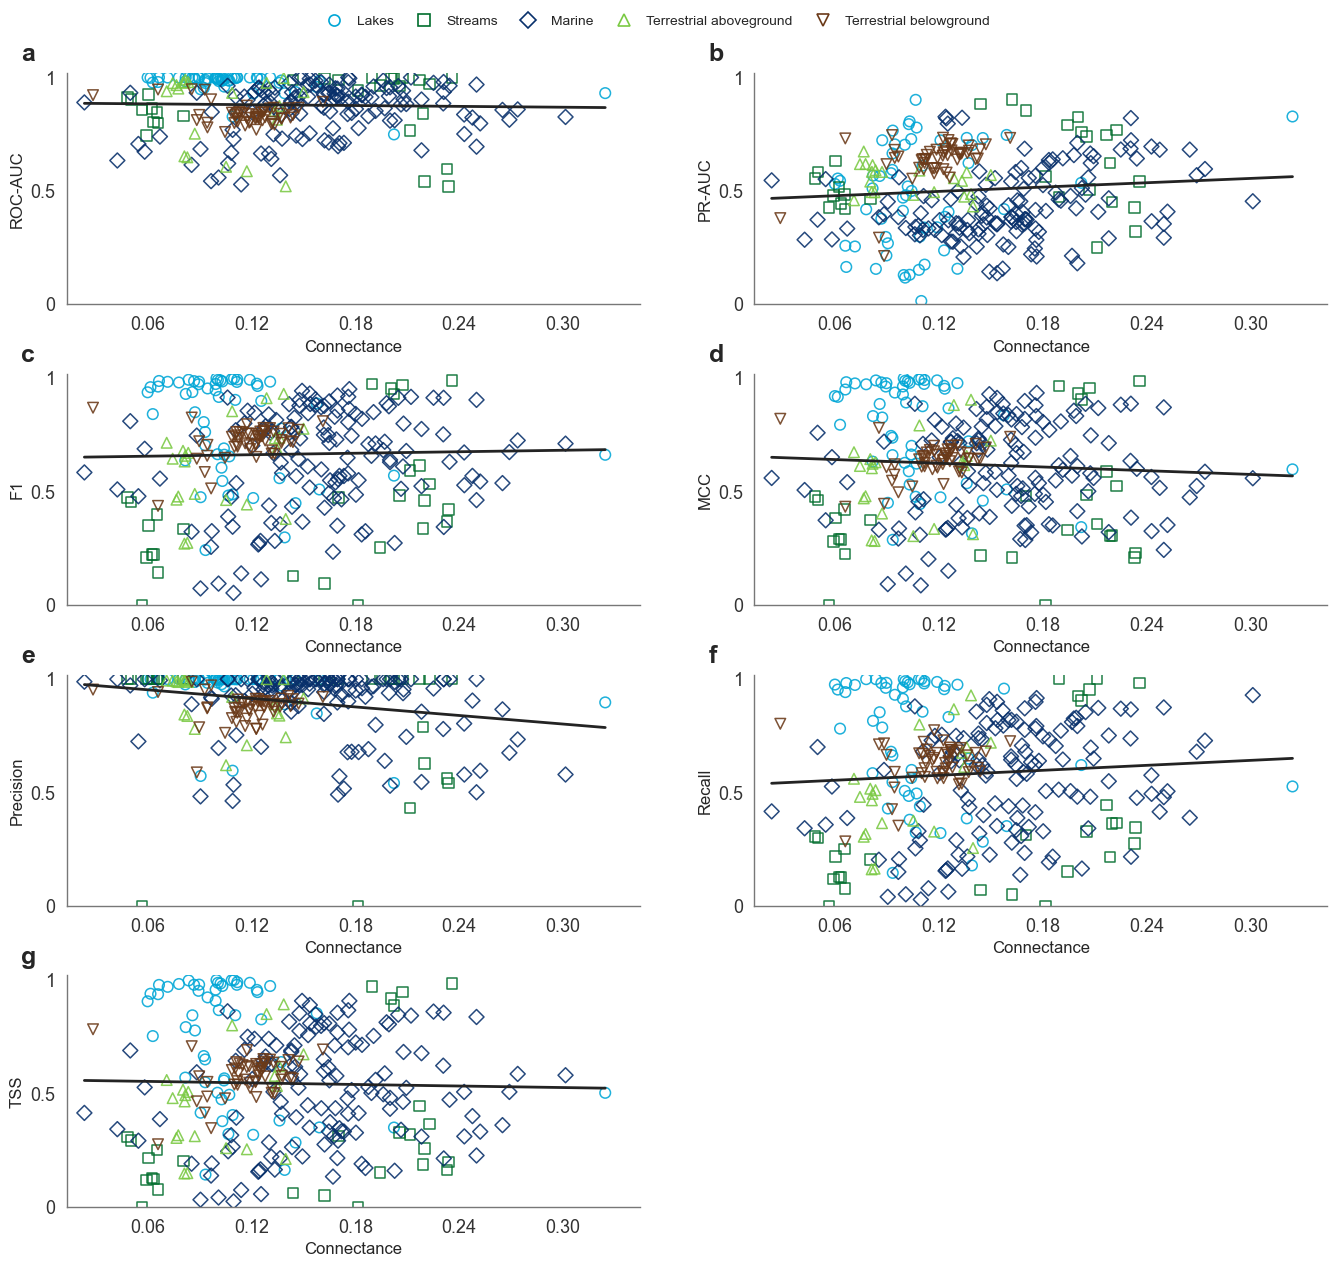

In [6]:
import os
import json
import math
import tempfile

from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(
        Path(tempfile.gettempdir())
        / "qmul_phd_framework_mplconfig"
    ),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from matplotlib.lines import Line2D


sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2,
)


# ============================================================
# Locate project root
# ============================================================

def find_project_root(start=None):
    start = (
        Path.cwd()
        if start is None
        else Path(start).resolve()
    )

    for path in [
        start,
        *start.parents,
    ]:
        if (
            (path / "src/matlab").is_dir()
            and (path / "docs").is_dir()
        ):
            return path

    raise FileNotFoundError(
        "Could not find project root from "
        "current working directory."
    )


PROJECT_ROOT = find_project_root()


# ============================================================
# Final role-only input configuration
# ============================================================

CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

EXPECTED_SCENARIO = (
    "role_only_5_role_constraints_"
    "checkconnfalse_adaptivefalse_threshold0p50"
)

RESULT_ROOT = (
    PROJECT_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_sweep_train_ratios_"
        "10-90_pseudo_properties_Apocrita_neg_const"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

PREDICTIVE_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / (
        f"predictive_train{int(TARGET_RATIO)}"
        "_after_tukey.csv"
    )
)

RETENTION_MANIFEST = (
    RETENTION_ROOT
    / "retention_manifest.json"
)

ECOSYSTEM_FILE = (
    PROJECT_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Figure configuration — preserved
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


def find_column(
    dataframe,
    candidates,
):
    norm_map = {
        normalize_colname(column): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        normalized_candidate = normalize_colname(
            candidate
        )

        if normalized_candidate in norm_map:
            return norm_map[
                normalized_candidate
            ]

    raise KeyError(
        "Could not find any of these columns: "
        f"{candidates}"
    )


def normalize_train_ratio(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    return np.where(
        values <= 1.0,
        values * 100.0,
        values,
    )


def format_ecosystem_label(name):
    name = str(
        name
    ).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": (
            "Terrestrial aboveground"
        ),
        "terrestrial belowground": (
            "Terrestrial belowground"
        ),
        "unknown": "Unknown",
    }

    return label_map.get(
        name,
        str(name).strip().capitalize(),
    )


def report_foodweb_count(
    stage_name,
    before,
    after,
):
    print(
        f"[CHECK] {stage_name}: "
        f"{len(before)} -> {len(after)} food webs"
    )


# ============================================================
# Validate selected inputs
# ============================================================

required_files = {
    "Tukey-filtered predictive input": (
        PREDICTIVE_INPUT
    ),
    "Food-web metadata": (
        ECOSYSTEM_FILE
    ),
    "Tukey retention manifest": (
        RETENTION_MANIFEST
    ),
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(
            missing_files
        )
    )


# ============================================================
# Validate final role-only configuration
# ============================================================

with RETENTION_MANIFEST.open(
    "r",
    encoding="utf-8",
) as handle:
    retention_manifest = json.load(handle)

manifest = retention_manifest.get(
    "source_manifest",
    {},
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "Condition": EXPECTED_SCENARIO,
    "Eligibility": "role_only",
    "MassEligibilityEnabled": "false",
    "NegativeSampling": (
        "uniform_role_pool_then_uniform_remaining_nonlinks_topup"
    ),
    "TargetNegativePositiveRatio": "2",
    "NumExperiments": "50",
    "TrainRatioRange": "0.10:0.10:0.90",
    "ClassificationThreshold": "0.50",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "FoodWebs": "290",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(
        key
    )

    if observed_value is None:
        configuration_errors.append(
            f"{key}: missing"
        )
    elif (
        str(observed_value).casefold()
        != str(expected_value).casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected_value}, "
            f"found {observed_value}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result directory does not match "
        "the final role-only configuration:\n\n"
        + "\n".join(
            configuration_errors
        )
    )

if (
    retention_manifest.get("scenario")
    != EXPECTED_SCENARIO
):
    raise ValueError(
        "Unexpected scenario in retention_manifest.json:\n"
        f"  expected: {EXPECTED_SCENARIO}\n"
        f"  observed: "
        f"{retention_manifest.get('scenario')}"
    )

observed_threshold = retention_manifest.get(
    "classification_threshold"
)

if (
    observed_threshold is None
    or not np.isclose(
        float(observed_threshold),
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
    )
):
    raise ValueError(
        "The Tukey retention protocol does not use "
        f"classification threshold "
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

print("[INFO] Validated final role-only configuration:")
print(f"  scenario={manifest['Condition']}")
print(f"  eligibility={manifest['Eligibility']}")
print(
    "  mass_eligibility_enabled="
    f"{manifest['MassEligibilityEnabled']}"
)
print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)
print(
    "  target_negative_positive_ratio="
    f"{manifest['TargetNegativePositiveRatio']}"
)
print(
    "  classification_threshold="
    f"{manifest['ClassificationThreshold']}"
)
print(
    "  check_connectivity="
    f"{manifest['CheckConnectivity']}"
)
print(
    "  adaptive_connectivity="
    f"{manifest['AdaptiveConnectivity']}"
)
print(
    "  number_of_experiments="
    f"{manifest['NumExperiments']}"
)
print(
    "  train_ratio_range="
    f"{manifest['TrainRatioRange']}"
)
print(f"  retention_protocol={PROTOCOL_NAME}")


# ============================================================
# Load Tukey-filtered results
# ============================================================

def load_results(path):
    results = pd.read_csv(
        path
    ).copy()

    required_columns = {
        "Scenario",
        "Foodweb",
        "Version",
        "K",
        "TrainRatio",
        "Threshold",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "OutlierRunsExcluded",
        "MeetsMinimumRetainedRuns",
    }

    missing_columns = sorted(
        required_columns.difference(
            results.columns
        )
    )

    if missing_columns:
        raise ValueError(
            "The Tukey-filtered input is missing columns:\n  "
            + "\n  ".join(
                missing_columns
            )
        )

    numeric_columns = [
        "K",
        "TrainRatio",
        "Threshold",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "OutlierRunsExcluded",
        "MeetsMinimumRetainedRuns",
    ]

    for column in numeric_columns:
        results[column] = pd.to_numeric(
            results[column],
            errors="coerce",
        )

    results[
        "TrainRatio"
    ] = normalize_train_ratio(
        results[
            "TrainRatio"
        ]
    )

    metric_columns = [
        metric
        for metric, _
        in METRIC_SPECS
    ]

    results = results.loc[
        results[
            "Scenario"
        ].eq(
            EXPECTED_SCENARIO
        )
        & results[
            "Version"
        ].eq(
            "WLNM_dir_neg"
        )
        & (
            results[
                "MetricFamily"
            ]
            .astype(str)
            .str.casefold()
            .eq("predictive")
        )
        & results[
            "Metric"
        ].isin(
            metric_columns
        )
        & np.isclose(
            results[
                "K"
            ],
            K_TARGET,
            atol=1e-9,
            equal_nan=False,
        )
        & np.isclose(
            results[
                "TrainRatio"
            ],
            TARGET_RATIO,
            atol=1e-9,
            equal_nan=False,
        )
        & np.isclose(
            results[
                "Threshold"
            ],
            CLASSIFICATION_THRESHOLD,
            atol=1e-9,
            equal_nan=False,
        )
        & results[
            "MeetsMinimumRetainedRuns"
        ].eq(1)
        & results[
            "MeanAfterTukey"
        ].notna()
    ].copy()

    if results.empty:
        raise RuntimeError(
            "No retained final role-only predictive "
            "results were found for "
            f"K={K_TARGET}, "
            f"TrainRatio={TARGET_RATIO}, "
            f"Threshold={CLASSIFICATION_THRESHOLD:.2f}."
        )

    results[
        "FoodwebKey"
    ] = results[
        "Foodweb"
    ].apply(
        normalize_foodweb_name
    )

    duplicated = results.duplicated(
        subset=[
            "FoodwebKey",
            "Metric",
        ],
        keep=False,
    )

    if duplicated.any():
        duplicated_rows = (
            results.loc[
                duplicated,
                [
                    "Foodweb",
                    "Metric",
                    "K",
                    "TrainRatio",
                    "Threshold",
                ],
            ]
            .sort_values(
                [
                    "Metric",
                    "Foodweb",
                ]
            )
        )

        print(duplicated_rows)

        raise ValueError(
            "More than one retained result was found per "
            "food web and metric."
        )

    wide_results = (
        results
        .pivot(
            index=[
                "Foodweb",
                "FoodwebKey",
                "K",
                "TrainRatio",
            ],
            columns="Metric",
            values="MeanAfterTukey",
        )
        .reset_index()
        .copy()
    )

    wide_results.columns.name = None

    missing_metrics = [
        metric
        for metric, _
        in METRIC_SPECS
        if metric not in wide_results.columns
    ]

    if missing_metrics:
        raise RuntimeError(
            "Missing required metric columns after "
            f"pivoting: {missing_metrics}"
        )

    print(
        "[INFO] Tukey-filtered input: "
        f"{path}"
    )

    print(
        "[INFO] Food webs in filtered result: "
        f"{wide_results['Foodweb'].nunique()}"
    )

    print(
        "[INFO] Configuration: "
        "eligibility=role_only, "
        "mass_constraint=False, "
        "random_topup=True, "
        "negative_positive_ratio=2:1, "
        "check_connectivity=False, "
        "adaptive_connectivity=False, "
        "classification_threshold=0.50."
    )

    return wide_results


# ============================================================
# Load food-web metadata
# ============================================================

def load_foodweb_metadata(path):
    metadata = pd.read_csv(
        path
    ).copy()

    foodweb_col = find_column(
        metadata,
        [
            "foodweb",
        ],
    )

    ecosystem_col = find_column(
        metadata,
        [
            "ecosystemtype",
            "ecosystem",
            "ecosystem_type",
        ],
    )

    nodes_col = find_column(
        metadata,
        [
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        ],
    )

    edges_col = find_column(
        metadata,
        [
            "edges",
            "n_edges",
            "num_edges",
            "edgecount",
            "l",
        ],
    )

    connectance_col = find_column(
        metadata,
        [
            "connectance",
            "c",
        ],
    )

    metadata = metadata.rename(
        columns={
            foodweb_col: (
                "MetadataFoodweb"
            ),
            ecosystem_col: (
                "EcosystemType"
            ),
            nodes_col: (
                "Nodes"
            ),
            edges_col: (
                "Edges"
            ),
            connectance_col: (
                "MetadataConnectance"
            ),
        }
    )

    metadata = metadata[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    metadata[
        "MetadataFoodweb"
    ] = metadata[
        "MetadataFoodweb"
    ].astype(str)

    metadata[
        "FoodwebKey"
    ] = metadata[
        "MetadataFoodweb"
    ].apply(
        normalize_foodweb_name
    )

    metadata[
        "EcosystemType"
    ] = (
        metadata[
            "EcosystemType"
        ]
        .astype(str)
        .str.strip()
    )

    metadata[
        "Nodes"
    ] = pd.to_numeric(
        metadata[
            "Nodes"
        ],
        errors="coerce",
    )

    metadata[
        "Edges"
    ] = pd.to_numeric(
        metadata[
            "Edges"
        ],
        errors="coerce",
    )

    metadata[
        "MetadataConnectance"
    ] = pd.to_numeric(
        metadata[
            "MetadataConnectance"
        ],
        errors="coerce",
    )

    duplicated_metadata = metadata.duplicated(
        subset=["FoodwebKey"],
        keep=False,
    )

    if duplicated_metadata.any():
        conflicting_metadata = (
            metadata.loc[
                duplicated_metadata,
                [
                    "FoodwebKey",
                    "EcosystemType",
                    "Nodes",
                    "Edges",
                    "MetadataConnectance",
                ],
            ]
            .groupby("FoodwebKey")
            .nunique(
                dropna=False
            )
        )

        conflicting_metadata = conflicting_metadata[
            conflicting_metadata.max(
                axis=1
            ) > 1
        ]

        if not conflicting_metadata.empty:
            print(conflicting_metadata)

            raise ValueError(
                "Conflicting metadata were found for "
                "one or more food webs."
            )

    metadata = (
        metadata
        .drop_duplicates(
            subset=[
                "FoodwebKey",
            ],
            keep="first",
        )
        .copy()
    )

    print(
        "[INFO] Food webs in metadata file: "
        f"{metadata['FoodwebKey'].nunique()}"
    )

    return metadata


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(
    results,
    metadata,
):
    dataframe = (
        results.merge(
            metadata,
            on="FoodwebKey",
            how="left",
            validate="one_to_one",
        )
        .copy()
    )

    missing_metadata = (
        dataframe[
            "EcosystemType"
        ].isna()
        | dataframe[
            "Nodes"
        ].isna()
    )

    if missing_metadata.any():
        missing_foodwebs = sorted(
            dataframe.loc[
                missing_metadata,
                "Foodweb",
            ]
            .astype(str)
            .unique()
        )

        raise ValueError(
            "Metadata could not be matched for "
            f"{len(missing_foodwebs)} food webs:\n  "
            + "\n  ".join(
                missing_foodwebs[:30]
            )
        )

    numeric_columns = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "Nodes",
        "Edges",
        "MetadataConnectance",
    ]

    existing_numeric_columns = [
        column
        for column in numeric_columns
        if column in dataframe.columns
    ]

    dataframe[
        existing_numeric_columns
    ] = dataframe[
        existing_numeric_columns
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    dataframe[
        "EmpiricalConnectanceForPlot"
    ] = dataframe[
        "MetadataConnectance"
    ]

    missing_connectance = (
        dataframe[
            "EmpiricalConnectanceForPlot"
        ].isna()
    )

    can_compute_connectance = (
        missing_connectance
        & dataframe[
            "Nodes"
        ].notna()
        & dataframe[
            "Edges"
        ].notna()
        & (
            dataframe[
                "Nodes"
            ]
            > 1
        )
    )

    dataframe.loc[
        can_compute_connectance,
        "EmpiricalConnectanceForPlot",
    ] = (
        dataframe.loc[
            can_compute_connectance,
            "Edges",
        ]
        / (
            dataframe.loc[
                can_compute_connectance,
                "Nodes",
            ]
            * (
                dataframe.loc[
                    can_compute_connectance,
                    "Nodes",
                ]
                - 1
            )
        )
    )

    dataframe[
        "EcosystemType"
    ] = dataframe[
        "EcosystemType"
    ].fillna(
        "Unknown"
    )

    before = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    if K_TARGET is not None:
        dataframe = dataframe.loc[
            np.isclose(
                dataframe[
                    "K"
                ],
                K_TARGET,
                atol=1e-9,
                equal_nan=False,
            )
        ].copy()

        after = set(
            dataframe[
                "Foodweb"
            ]
            .dropna()
            .unique()
        )

        report_foodweb_count(
            f"K = {K_TARGET}",
            before,
            after,
        )

        before = after

    dataframe = dataframe.loc[
        np.isclose(
            dataframe[
                "TrainRatio"
            ],
            TARGET_RATIO,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    after = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    report_foodweb_count(
        f"TrainRatio = {TARGET_RATIO}",
        before,
        after,
    )

    before = after

    dataframe = dataframe.loc[
        dataframe[
            "Nodes"
        ].ge(
            MIN_NODES
        )
    ].copy()

    after = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    report_foodweb_count(
        f"Nodes >= {MIN_NODES}",
        before,
        after,
    )

    missing_metrics = [
        metric
        for metric, _
        in METRIC_SPECS
        if metric not in dataframe.columns
    ]

    if missing_metrics:
        raise RuntimeError(
            "Missing required metric columns: "
            f"{missing_metrics}"
        )

    if AGGREGATE_REPEATS:
        group_columns = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_columns = [
            metric
            for metric, _
            in METRIC_SPECS
        ]

        dataframe = (
            dataframe
            .groupby(
                group_columns,
                dropna=False,
                as_index=False,
            )[
                mean_columns
            ]
            .mean()
            .copy()
        )

    before_connectance = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    dataframe = (
        dataframe
        .dropna(
            subset=[
                "EmpiricalConnectanceForPlot",
            ]
        )
        .copy()
    )

    after_connectance = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    report_foodweb_count(
        "available connectance for x-axis",
        before_connectance,
        after_connectance,
    )

    metric_columns = [
        metric
        for metric, _
        in METRIC_SPECS
    ]

    metric_availability = (
        dataframe[
            [
                "Foodweb",
                *metric_columns,
            ]
        ]
        .assign(
            HasAnySelectedMetric=lambda frame: (
                frame[
                    metric_columns
                ]
                .notna()
                .any(
                    axis=1
                )
            )
        )
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability[
                "HasAnySelectedMetric"
            ],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(
        "[FINAL] Food webs retained after "
        "structural filters: "
        f"{dataframe['Foodweb'].nunique()}"
    )

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted "
            "because all selected metrics are missing:"
        )

        for foodweb in foodwebs_without_metrics:
            print(
                f"  - {foodweb}"
            )

    return dataframe.copy()


# ============================================================
# Regression helpers — preserved
# ============================================================

def fit_linear_regression(
    data,
    metric,
    n_points=100,
):
    work = (
        data[
            [
                "EmpiricalConnectanceForPlot",
                metric,
            ]
        ]
        .dropna()
        .copy()
    )

    if work.empty:
        return None

    work[
        "EmpiricalConnectanceForPlot"
    ] = work[
        "EmpiricalConnectanceForPlot"
    ].astype(float)

    work[
        metric
    ] = work[
        metric
    ].astype(float)

    if (
        len(work) < 3
        or work[
            "EmpiricalConnectanceForPlot"
        ].nunique() < 2
    ):
        return None

    x = work[
        [
            "EmpiricalConnectanceForPlot",
        ]
    ]

    y = work[
        metric
    ]

    x_model = sm.add_constant(
        x,
        has_constant="add",
    )

    model = sm.OLS(
        y,
        x_model,
    ).fit()

    intercept = model.params[
        "const"
    ]

    slope = model.params[
        "EmpiricalConnectanceForPlot"
    ]

    x_line = np.linspace(
        work[
            "EmpiricalConnectanceForPlot"
        ].min(),
        work[
            "EmpiricalConnectanceForPlot"
        ].max(),
        n_points,
    )

    x_line_model = pd.DataFrame({
        "EmpiricalConnectanceForPlot": (
            x_line
        )
    })

    x_line_model = sm.add_constant(
        x_line_model,
        has_constant="add",
    )

    y_line = model.predict(
        x_line_model
    )

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues[
            "EmpiricalConnectanceForPlot"
        ],
        "f_value": model.fvalue,
        "df_model": int(
            model.df_model
        ),
        "df_resid": int(
            model.df_resid
        ),
        "n": len(work),
        "model": model,
    }


def format_equation(
    slope,
    intercept,
):
    sign = (
        "+"
        if intercept >= 0
        else "-"
    )

    return (
        f"y = {slope:.4f}x "
        f"{sign} {abs(intercept):.4f}"
    )


def format_p_value(p_value):
    if pd.isna(p_value):
        return "P = NA"

    if p_value < 0.0001:
        return "P < 0.0001"

    return (
        f"P = {p_value:.4f}"
    )


# ============================================================
# Plotting — original styling preserved
# ============================================================

def style_axes(
    ax,
    ylabel,
):
    ax.set_ylabel(
        ylabel,
        fontsize=12,
    )

    ax.set_xlabel(
        "Connectance",
        fontsize=12,
    )

    ax.grid(
        False
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.spines[
        "left"
    ].set_color(
        "#777777"
    )

    ax.spines[
        "bottom"
    ].set_color(
        "#777777"
    )

    ax.tick_params(
        axis="both",
        colors="#333333",
        labelsize=13,
    )


def plot_performance_vs_connectance(
    plot_dataframe,
):
    available_ecosystems = (
        plot_dataframe[
            "EcosystemType"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    available_by_label = {
        format_ecosystem_label(
            ecosystem
        ): ecosystem
        for ecosystem
        in available_ecosystems
    }

    eco_order = [
        available_by_label[label]
        for label in ECOSYSTEM_ORDER
        if label in available_by_label
    ]

    eco_order += [
        ecosystem
        for ecosystem
        in available_ecosystems
        if ecosystem
        not in eco_order
    ]

    plot_dataframe = (
        plot_dataframe.copy()
    )

    plot_dataframe[
        "EcosystemType"
    ] = pd.Categorical(
        plot_dataframe[
            "EcosystemType"
        ],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        ecosystem: ecosystem_palette.get(
            format_ecosystem_label(
                ecosystem
            ),
            "#999999",
        )
        for ecosystem
        in eco_order
    }

    eco_markers = {
        ecosystem: ecosystem_markers.get(
            format_ecosystem_label(
                ecosystem
            ),
            "o",
        )
        for ecosystem
        in eco_order
    }

    n_panels = len(
        METRIC_SPECS
    )

    n_rows = math.ceil(
        n_panels / N_COLS
    )

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(
            14,
            14,
        ),
        sharex=False,
        sharey=False,
    )

    axes = np.array(
        axes
    ).reshape(-1)

    panel_letters = list(
        "abcdefghijklmnopqrstuvwxyz"
    )

    x_min = plot_dataframe[
        "EmpiricalConnectanceForPlot"
    ].min()

    x_max = plot_dataframe[
        "EmpiricalConnectanceForPlot"
    ].max()

    print(
        "\n=== OLS linear regression: "
        "metric ~ empirical connectance ==="
    )

    for index, (
        (
            metric,
            label,
        ),
        ax,
    ) in enumerate(
        zip(
            METRIC_SPECS,
            axes,
        )
    ):
        data = (
            plot_dataframe
            .dropna(
                subset=[
                    "EmpiricalConnectanceForPlot",
                    metric,
                ]
            )
            .copy()
        )

        for ecosystem in eco_order:
            ecosystem_data = data.loc[
                data[
                    "EcosystemType"
                ]
                == ecosystem
            ]

            if ecosystem_data.empty:
                continue

            ax.scatter(
                ecosystem_data[
                    "EmpiricalConnectanceForPlot"
                ],
                ecosystem_data[
                    metric
                ],
                marker=eco_markers[
                    ecosystem
                ],
                facecolors="none",
                edgecolors=eco_palette[
                    ecosystem
                ],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(
                    ecosystem
                ),
            )

        fit = fit_linear_regression(
            data,
            metric,
        )

        if fit is not None:
            ax.plot(
                fit[
                    "x_line"
                ],
                fit[
                    "y_line"
                ],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(
                fit[
                    "slope"
                ],
                fit[
                    "intercept"
                ],
            )

            p_text = format_p_value(
                fit[
                    "p_value"
                ]
            )

            print(
                f"{panel_letters[index]}) "
                f"{label}: "
                f"{equation}; "
                f"F{fit['df_model']},"
                f"{fit['df_resid']} = "
                f"{fit['f_value']:.4f}; "
                f"R² = "
                f"{fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[index]}) "
                f"{label}: "
                "regression not fitted; "
                "insufficient data."
            )

        style_axes(
            ax,
            label,
        )

        ax.set_ylim(
            Y_MIN,
            Y_MAX + Y_PAD_TOP,
        )

        ax.set_xlim(
            max(
                0.0,
                x_min - 0.01,
            ),
            x_max + 0.02,
        )

        ax.set_yticks([
            0,
            0.5,
            1.0,
        ])

        ax.set_yticklabels([
            "0",
            "0.5",
            "1",
        ])

        ax.xaxis.set_major_locator(
            plt.MaxNLocator(6)
        )

        ax.text(
            -0.08,
            1.03,
            panel_letters[
                index
            ],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for panel_index in range(
        n_panels,
        len(axes),
    ):
        axes[
            panel_index
        ].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[
                ecosystem
            ],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[
                ecosystem
            ],
            markeredgewidth=1.2,
            label=format_ecosystem_label(
                ecosystem
            ),
        )
        for ecosystem
        in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.95,
        ),
        ncol=min(
            len(eco_order),
            5,
        ),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(
    PREDICTIVE_INPUT
)

metadata = load_foodweb_metadata(
    ECOSYSTEM_FILE
)

plot_df = prepare_plot_data(
    results,
    metadata,
)

fig = plot_performance_vs_connectance(
    plot_df
)

plt.show()